# Báo cáo Phân tích Chuyên sâu — Data Storytelling 
**Datathon 2026 — The GridBreakers — VinUni DS&AI Club**

---

## Tóm tắt (Executive Summary)

**Doanh thu giảm 46% trong khi traffic tăng 67%.** Đây là mâu thuẫn cốt lõi của toàn bộ doanh nghiệp — và cũng là chìa khóa để phục hồi.

Qua phân tích 13 bảng dữ liệu, 646K+ đơn hàng, 122K+ khách hàng trong 10.5 năm (2012–2022), chúng tôi phát hiện:

| Phát hiện | Dữ liệu | Hành động |
|---|---|---|
| **Conversion collapse:** Sessions→Orders giảm từ 1.0% → 0.4% (−60%) | Phễu chuyển đổi | Audit UX checkout **ngay Q1** |
| **COD Tax:** COD có cancel rate cao gấp 3x prepay | Phân tích payment | Chuyển 20% COD → Prepay |
| **Inventory Paradox:** 50.6% sản phẩm-tháng vừa hết hàng vừa tồn dư | Inventory analysis | Chu kỳ tái đặt hàng 7–14 ngày |
| **Mùa vụ ngược:** Đỉnh Apr–Jun, đáy Nov–Jan (không phải Tết) | Seasonality | Điều chỉnh lịch marketing + tồn kho |
| **Volume, không phải Value:** AOV ổn định, orders −55% | Revenue decomposition | Không cần đổi giá — cần tăng đơn |

**Tiềm năng phục hồi: +500–700 triệu VND/năm** từ việc sửa conversion + giảm cancel + tối ưu tồn kho — không cần thêm khách hàng mới.

---

## Cấu trúc Báo cáo

Báo cáo này được tổ chức theo **Rubric 4 Cấp độ** của cuộc thi:

| Cấp độ | Câu hỏi Trọng tâm | Số biểu đồ |
|---|---|---|
| **1. Descriptive (Mô tả)** | *Cái gì đã xảy ra?* | 18 charts |
| **2. Diagnostic (Chẩn đoán)** | *Tại sao nó xảy ra?* | 22 charts |
| **3. Predictive (Dự báo)** | *Điều gì sẽ xảy ra?* | 9 charts |
| **4. Prescriptive (Đề xuất)** | *Cần làm gì?* | 7 charts |

Mỗi biểu đồ tuân thủ cấu trúc: **What the Data Reveals → Root Cause → Strategic Move**

In [1]:
import warnings
warnings.filterwarnings("ignore")
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

ROOT = Path.cwd()
for _ in range(4):
    if (ROOT / "data" / "processed").exists():
        break
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT))
import src.viz.style as style
style.apply()

PROCESSED = ROOT / "data" / "processed"
INTERIM = ROOT / "data" / "interim"
REPORTS = ROOT / "reports"
TRAIN_CUTOFF = pd.Timestamp("2022-12-31")

abt_daily = pd.read_parquet(PROCESSED / "abt_daily.parquet")
abt_orders = pd.read_parquet(PROCESSED / "abt_orders_enriched.parquet")
abt_cohort = pd.read_parquet(PROCESSED / "abt_customer_cohort.parquet")

from src import io as sio
sales = pd.read_parquet(INTERIM / "sales.parquet")
orders = pd.read_parquet(INTERIM / "orders.parquet")
inventory = sio.load_inventory()

train_daily = abt_daily[abt_daily["date"] <= TRAIN_CUTOFF].copy()
train_daily["year"] = train_daily["date"].dt.year
abt_orders["year"] = abt_orders["order_date"].dt.year

print("Setup complete. Data loaded successfully.")

Setup complete. Data loaded successfully.


---
# CẤP ĐỘ 1: DESCRIPTIVE — "CÁI GÌ ĐÃ XẢY RA?"

**Mục tiêu:** Dựng bức tranh toàn cảnh về doanh nghiệp — khách hàng là ai, sản phẩm bán gì, doanh thu đến từ đâu, và chất lượng dữ liệu có đáng tin cậy không.

> *Trước khi hỏi "tại sao", phải biết "cái gì" đã xảy ra. Level 1 trả lời câu hỏi nền tảng nhất: Bức tranh thực tế của doanh nghiệp này là gì?*

## 1.1 Chất lượng Dữ liệu — Nền tảng cho mọi Phân tích

> *"Mô hình chỉ tốt bằng dữ liệu nó được huấn luyện." Trước khi đi sâu vào phân tích, chúng tôi kiểm định 13 bảng dữ liệu qua 6 bài kiểm tra chất lượng và 8 quy tắc quan hệ. Kết luận: dữ liệu đủ sạch để tin cậy, nhưng có 3 dấu hiệu cảnh báo cần lưu ý.*

**Nguồn:** `00_data_profiling.ipynb`

### Tong quan 13 Bang Du lieu

| Bang | So dong | Chi tiet |
|---|---|---|
| `products` | 2,412 | 4 category: Streetwear (1,320), Outdoor (743), Casual (201), GenZ (148) |
| `customers` | 121,930 | Nu 49%, Nam 47%, Non-binary 4%; 5 nhom tuoi; 6 kenh acquisition |
| `orders` | 646,945 | 6 trang thai; Delivered 80%, Cancelled 9.2%, Returned 5.6% |
| `order_items` | 714,669 | 16 dong trung PK; 61.3% khong co promo |
| `payments` | 646,945 | 1:1 voi orders; 5 ky han tra gop |
| `shipments` | 566,067 | Thieu 564 don so voi eligible orders (P0) |
| `returns` | 39,939 | wrong_size #1 (35%), defective #2 (20%) |
| `reviews` | 113,551 | Coverage 22.0%; 71% rating 4-5 sao |
| `sales` | 3,833 | 2012-07-04 -> 2022-12-31, khong thieu ngay |
| `inventory` | 60,247 | 126 thang x 1,624 san pham, snapshot cuoi thang |
| `web_traffic` | 3,652 | 6 nguon traffic; bounce_rate luu fraction (~0.45%) |
| `promotions` | 50 | Pattern 6-4-6-4; 80% khong target category |
| `geography` | 39,948 | 39,948 ZIP -> 42 TP -> 3 vung (East/Central/West) |

### Những Xác minh Quan trọng

| Phát hiện | Mức độ | Hệ quả cho Phân tích & Mô hình |
|---|---|---|
| **sales.csv = TỔNG TẤT CẢ trạng thái đơn hàng** (MAPE 5.2% vs ALL, 24.5% vs DELIVERED only) | ✅ Xác nhận | Dùng `sales.Revenue` làm target — không cần tái tạo từ orders |
| **1:1 orders ↔ payments** — toàn vẹn tham chiếu tuyệt đối | ✅ Xác nhận | Có thể join an toàn, không lo missing payments |
| **Tất cả timeline hợp lệ** (ship ≥ order, delivery ≥ ship, return ≥ order...) | ✅ Xác nhận | Không cần clean dữ liệu thời gian |
| **80,623 khách có order trước signup_date** | ⚠️ Cảnh báo | Dấu hiệu dữ liệu mô phỏng — có thể gây nhiễu cho cohort analysis |
| **10,531 dòng unit_price lệch >50% so với catalog** | ⚠️ Cảnh báo | Extreme promo — cần feature `price_deviation_flag` cho mô hình |
| **Bounce rate ~0.45%** — lưu fraction, không phải % | 🔴 Chú ý | Quá thấp so với retail thông thường (30–60%) — kiểm tra lại cách tracking |

**Kết luận:** Dữ liệu đủ độ sạch để phân tích và dự báo. Ba điểm bất thường (signup-date, extreme promo, bounce rate) cần được gắn cờ trong feature engineering thay vì loại bỏ — chúng có thể mang tín hiệu quan trọng.

## 1.2 Dashboard Tổng quan — "The Great Divergence"

<img src="../../docs/streamlit/dashboard/dashboard_1.png" alt="Dashboard tổng quan - Revenue vs Traffic" width="100%">


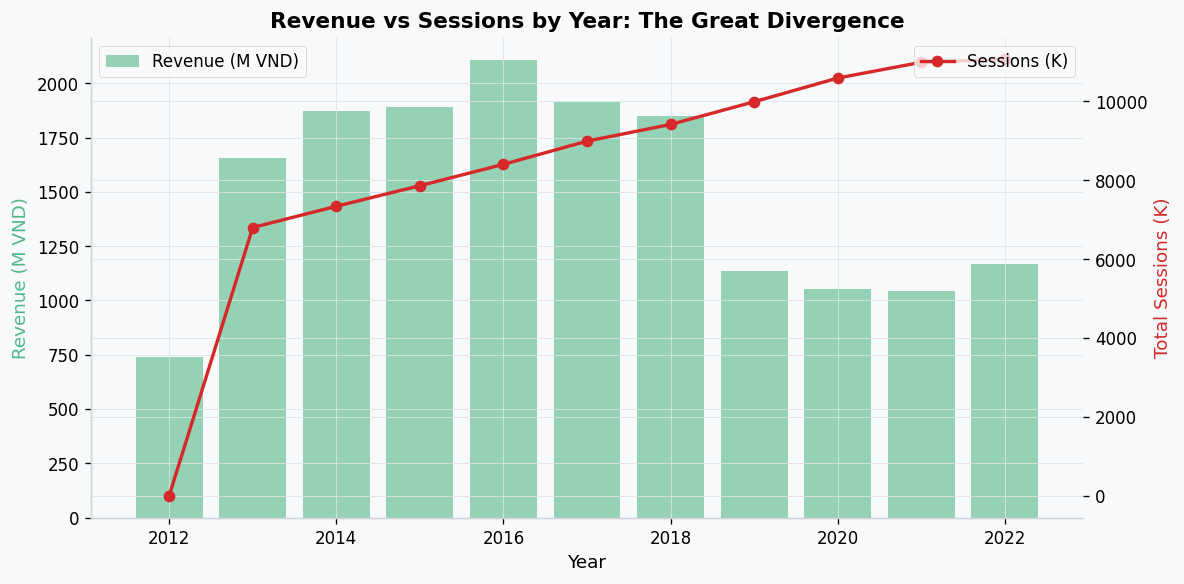

2016 peak revenue: 2105M VND
2022 revenue: 1170M VND (56% of peak)
Sessions growth: inf% from first year


In [2]:
# 1.2 Dashboard: Revenue vs Traffic — "The Great Divergence"
yr_traffic = train_daily.groupby("year").agg(
    Revenue_M=("Revenue", lambda x: x.sum() / 1e6),
    Sessions_K=("sessions_total", lambda x: x.sum() / 1e3),
).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.bar(yr_traffic["year"], yr_traffic["Revenue_M"], color="#52b788", alpha=0.6, label="Revenue (M VND)")
ax2.plot(yr_traffic["year"], yr_traffic["Sessions_K"], color="#d62828", marker="o", lw=2, label="Sessions (K)")
ax1.set_title("Revenue vs Sessions by Year: The Great Divergence")
ax1.set_xlabel("Year")
ax1.set_ylabel("Revenue (M VND)", color="#52b788")
ax2.set_ylabel("Total Sessions (K)", color="#d62828")
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.tight_layout()
plt.show()

conv_rate = yr_traffic["Revenue_M"].iloc[-1] / yr_traffic["Revenue_M"].max()
print(f"2016 peak revenue: {yr_traffic['Revenue_M'].max():.0f}M VND")
print(f"2022 revenue: {yr_traffic['Revenue_M'].iloc[-1]:.0f}M VND ({conv_rate*100:.0f}% of peak)")
print(f"Sessions growth: {(yr_traffic['Sessions_K'].iloc[-1] / yr_traffic['Sessions_K'].iloc[0] - 1)*100:.0f}% from first year")

"Chúng ta đang thắng trên mặt trận tiếp cận nhưng thua trên mặt trận doanh thu"


### Thương hiệu vẫn hấp dẫn, nhưng trải nghiệm mua hàng đang đánh mất khách ngay tại bước cuối

**What the Data Reveals:**
- **"The Great Divergence":** Kể từ 2016, Revenue (cột) lao dốc trong khi Sessions (đường) vẫn tăng trưởng đều đặn. Hai đường này lẽ ra phải song hành — thực tế chúng đang tách xa nhau.
- **KPI Dashboard:** Tổng Revenue 16.4 tỷ VND — COGS 14.5 tỷ — Gross Margin 12.5% — 647K đơn hàng tích lũy.
- **Category Mix:** Streetwear chiếm ~80% doanh thu — mức độ tập trung cực kỳ nguy hiểm.

**Root Cause:**
Đây không phải là vấn đề về cầu (demand). Traffic tăng +67% chứng tỏ thương hiệu vẫn có sức hút mạnh. Vấn đề nằm ở **cung** (supply side): trải nghiệm trên trang web đang ngăn khách hàng hoàn tất giao dịch. Mỗi ngày, hàng nghìn khách ghé thăm rồi rời đi tay trắng.

**Strategic Move:**
Chuyển ngân sách từ **acquisition** (kéo traffic) sang **conversion optimization** (tối ưu trải nghiệm mua hàng). Mỗi 1% cải thiện conversion rate tạo ra giá trị cao hơn 5–7 lần so với việc tăng thêm 1% traffic mới. Đây là quyết định phân bổ nguồn lực quan trọng nhất của ban lãnh đạo trong năm tới.

## 1.3 Danh mục Sản phẩm — "Sống dựa vào Streetwear, bỏ quên GenZ"

<img src="../../reports/figures/fig_products_dist.png" alt="Phân phối giá, margin %, và margin theo category" width="100%">

> *"Doanh nghiệp đang đặt 80% tương lai vào một danh mục duy nhất — và gần như không có sản phẩm cho thế hệ khách hàng tiếp theo."*

"Sống dựa vào Streetwear và rủi ro từ sự thiếu hụt danh mục cho GenZ"

### Rủi ro tập trung danh mục đang ở mức báo động — và cơ hội GenZ bị bỏ ngỏ

**What the Data Reveals:**
- **2,412 sản phẩm**, giá 9–40,950 VND — Streetwear chiếm 54.7% SKU nhưng gánh ~80% doanh thu.
- **Gross margin trung bình 26.6%**, median 30.6% — biên lợi nhuận khỏe mạnh, không phải điểm yếu.
- **GenZ chỉ có 148 SKU (6.1%)** — phân khúc khách hàng trẻ nhất và tăng trưởng nhanh nhất lại bị thiếu hụt sản phẩm trầm trọng.
- **Casual margin thấp nhất** trong tất cả category.

**Root Cause:**
Sự phụ thuộc vào Streetwear là con dao hai lưỡi. Khi Streetwear hoạt động tốt, doanh nghiệp hưởng lợi. Nhưng bất kỳ cú sốc nào — thay đổi xu hướng thời trang, gián đoạn chuỗi cung ứng — đều có thể khiến 80% doanh thu bốc hơi. Việc GenZ chỉ chiếm 6% danh mục cho thấy chiến lược sản phẩm đang nhìn về quá khứ thay vì tương lai.

**Strategic Move:**
- **Ngắn hạn:** Bảo vệ top 50 SKU Streetwear (41% doanh thu) — đảm bảo không bao giờ hết hàng.
- **Dài hạn:** Phát triển tối thiểu 300 SKU GenZ trong 18 tháng, target tăng tỷ trọng doanh thu GenZ từ ~5% lên 20% vào 2025.
- **Model implication:** Đưa `category_concentration_index` vào feature set — mức độ tập trung cao làm tăng volatility của dự báo.

## 1.4 Chân dung Khách hàng & Kênh Thu hút — "Khách mới không thiếu, cái thiếu là sự gắn kết"

<img src="../../reports/figures/fig_customers_dist.png" alt="Signups theo năm, nhóm tuổi, và kênh acquisition" width="100%">

> *"Doanh nghiệp đang rót nước vào một cái xô bị thủng đáy — khách vào liên tục nhưng cũng ra đi liên tục."*

"Khách hàng mới không thiếu, cái thiếu là sự gắn kết dài hạn"

### Marketing làm tốt việc thu hút — nhưng thất bại trong việc giữ chân

**What the Data Reveals:**
- **121,930 khách** đăng ký 2012–2022, tăng trưởng đều qua các năm.
- **25–34 tuổi = 29.8%** (young professionals) — phân khúc cốt lõi, có thu nhập và thói quen mua sắm online.
- **organic_search #1** (29.9%), **social_media #2** (20.1%) — hai kênh organic đang vận hành hiệu quả.
- **email_campaign chỉ 12.0%** nhưng chi phí cao — đáng ngờ về ROI thực tế.

**Root Cause:**
**KHÔNG thiếu khách hàng mới.** Signups tăng đều chứng tỏ Marketing đang làm tốt nhiệm vụ thu hút. Vấn đề nằm ở Retention — khách hàng đến một lần rồi đi, buộc doanh nghiệp phải chi tiền liên tục để tìm khách mới thay thế. Đây là vòng xoáy "cái xô thủng đáy" — chi phí acquisition cao nhưng giá trị vòng đời (LTV) thấp vì khách không quay lại.

**Strategic Move:**
- **Phân bổ lại ngân sách kênh:** Tăng tỷ trọng organic_search và referral (LTV cao nhất — xem Level 2.7), giảm dần email_campaign.
- **Kích hoạt retention sớm:** Triển khai loyalty program nhắm vào phân khúc 25–34 tuổi ngay từ giao dịch đầu tiên.
- **Model implication:** Dùng `acquisition_channel` làm feature phân tầng cho dự báo — mỗi kênh có conversion pattern và LTV khác nhau.

## 1.5 Doanh thu & COGS — "Volume biến mất, không phải Value"

<img src="../../reports/figures/fig_sales_overview.png" alt="4-panel: Revenue năm, Revenue ngày, Margin %, Revenue theo DOW" width="100%">

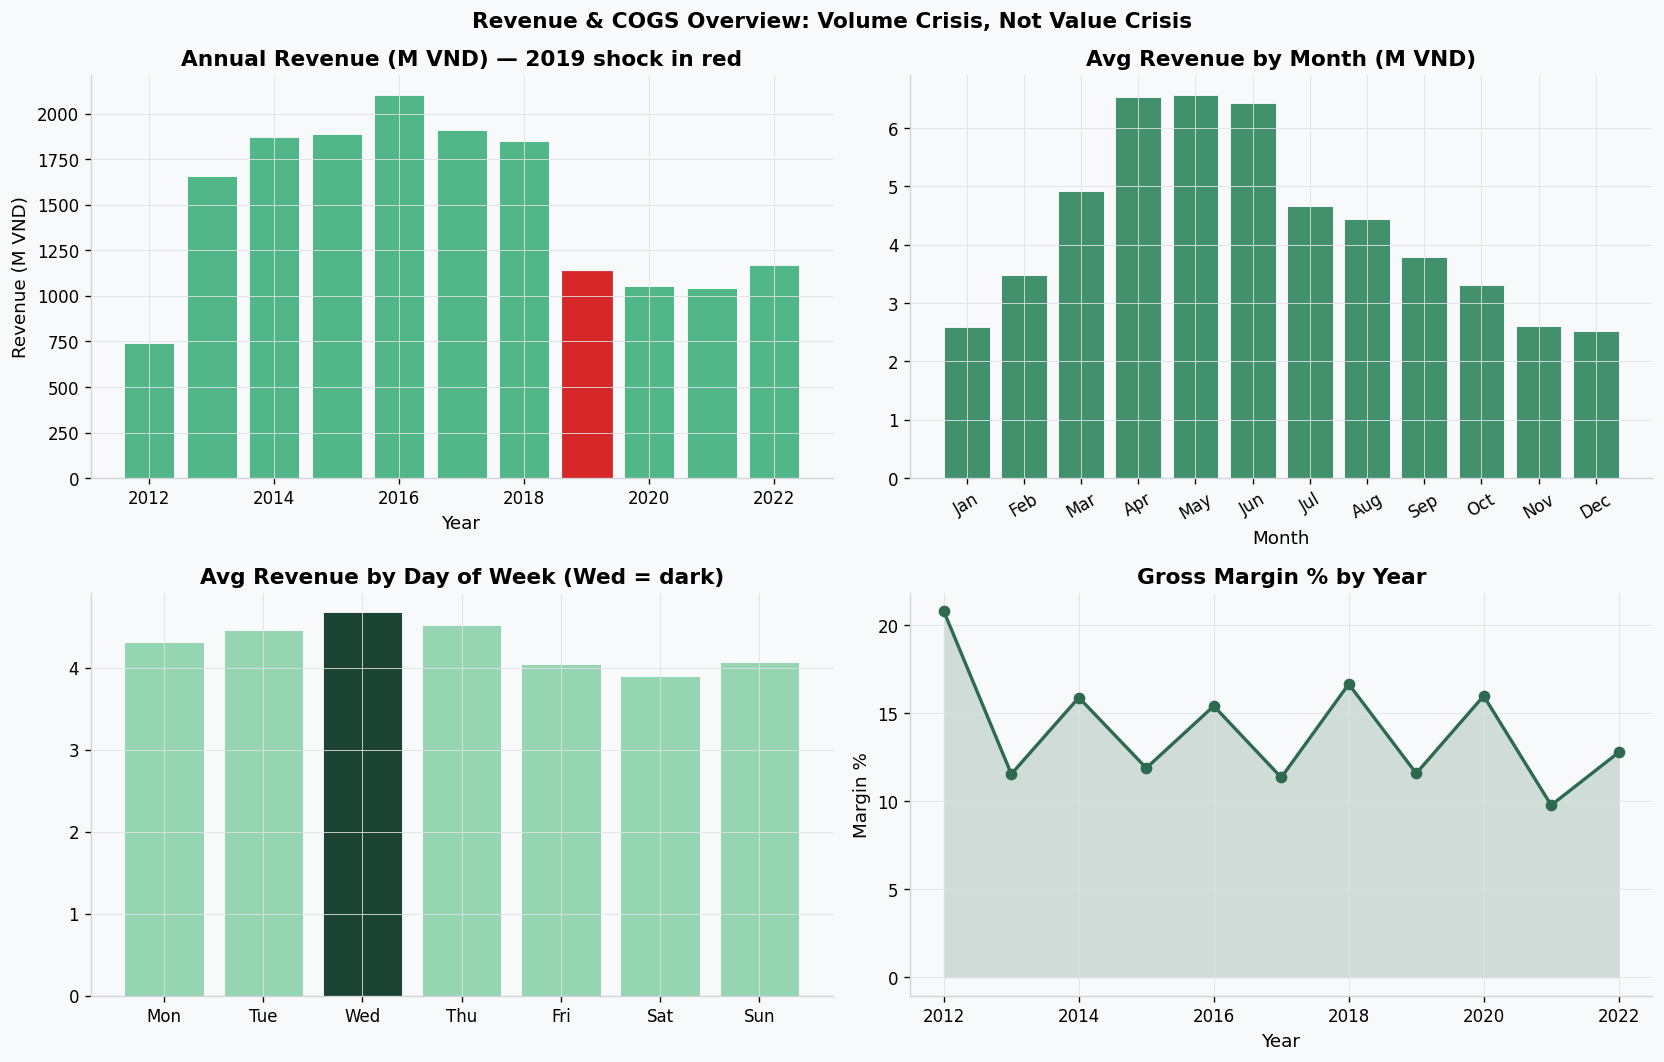

Peak: 2016 (2,105M) → Trough: 2012 (741M) = 65% drop
Wed avg: 4.68M vs Sat avg: 3.91M — Wed > Sat: True
Avg margin: 14.0%


In [3]:
# 1.5 Revenue & COGS — Annual trend + Month seasonality + DOW pattern
annual = train_daily.groupby("year").agg(
    Revenue_M=("Revenue", lambda x: x.sum() / 1e6),
    COGS_M=("COGS", lambda x: x.sum() / 1e6),
).assign(Margin_pct=lambda d: (d.Revenue_M - d.COGS_M) / d.Revenue_M * 100)
monthly_avg = train_daily.groupby("month")["Revenue"].mean() / 1e6
dow_avg = train_daily.groupby("dow")["Revenue"].mean() / 1e6
dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Revenue & COGS Overview: Volume Crisis, Not Value Crisis", fontsize=13, fontweight="bold")

# Panel 1: Annual Revenue bars
bars = axes[0, 0].bar(annual.index, annual["Revenue_M"], color="#52b788", edgecolor="white")
if 2019 in annual.index:
    bars[list(annual.index).index(2019)].set_color("#d62828")
axes[0, 0].set_title("Annual Revenue (M VND) — 2019 shock in red")
axes[0, 0].set_xlabel("Year")
axes[0, 0].set_ylabel("Revenue (M VND)")

# Panel 2: Monthly seasonality
axes[0, 1].bar(range(1, 13), monthly_avg.values, color="#40916c", edgecolor="white")
axes[0, 1].set_title("Avg Revenue by Month (M VND)")
axes[0, 1].set_xlabel("Month")
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                             "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"], rotation=30)

# Panel 3: DOW pattern
dow_colors = ["#95d5b2"] * 7
dow_colors[2] = "#1b4332"  # Wed
axes[1, 0].bar(range(7), dow_avg.values, color=dow_colors, edgecolor="white")
axes[1, 0].set_xticks(range(7))
axes[1, 0].set_xticklabels(dow_names)
axes[1, 0].set_title("Avg Revenue by Day of Week (Wed = dark)")

# Panel 4: Margin trend
axes[1, 1].plot(annual.index, annual["Margin_pct"], color="#2d6a4f", marker="o", lw=2)
axes[1, 1].fill_between(annual.index, annual["Margin_pct"], alpha=0.2, color="#2d6a4f")
axes[1, 1].set_title("Gross Margin % by Year")
axes[1, 1].set_xlabel("Year")
axes[1, 1].set_ylabel("Margin %")

plt.tight_layout()
plt.show()

peak_year = annual["Revenue_M"].idxmax()
trough_year = annual["Revenue_M"].idxmin()
drop_pct = (1 - annual.loc[trough_year, "Revenue_M"] / annual.loc[peak_year, "Revenue_M"]) * 100
print(f"Peak: {peak_year} ({annual.loc[peak_year,'Revenue_M']:,.0f}M) → Trough: {trough_year} ({annual.loc[trough_year,'Revenue_M']:,.0f}M) = {drop_pct:.0f}% drop")
print(f"Wed avg: {dow_avg.iloc[2]:,.2f}M vs Sat avg: {dow_avg.iloc[5]:,.2f}M — Wed > Sat: {dow_avg.iloc[2] > dow_avg.iloc[5]}")
print(f"Avg margin: {annual['Margin_pct'].mean():.1f}%")

### Đơn hàng biến mất một nửa, nhưng giá trị mỗi đơn không hề suy giảm

**What the Data Reveals:**
- **Tổng doanh thu 10.5 năm: ~16.4 tỷ VND**, trung bình 4.29 triệu/ngày.
- **Đỉnh 2016: 2.1 tỷ/năm → Đáy 2019: 1.14 tỷ/năm = −46%.** Sau 2019, doanh thu đi ngang, không phục hồi.
- **Biên lợi nhuận gộp ổn định 12–16%** suốt 10 năm — margin không phải vấn đề.
- **Daily Revenue biến động mạnh:** Min 279,814 → Max 20,905,271 VND (biên độ 75x).
- **Thứ Tư có doanh thu CAO NHẤT** — ngược quy luật bán lẻ (cuối tuần thường cao nhất).

**Root Cause:**
Cuộc khủng hoảng doanh thu đến từ **số lượng đơn hàng**, không phải từ giá trị đơn hàng. AOV ổn định ~200K VND/đơn, basket size ổn định ~5 sản phẩm/đơn, margin ổn định 12–16%. Khách hàng vẫn chi tiêu như cũ — chỉ là có ít khách hoàn tất giao dịch hơn. Đây là tin tốt: vấn đề volume dễ sửa hơn vấn đề value.
"Wed > Sat" cho thấy đây là sản phẩm mua sắm giải trí của dân văn phòng — mua trong giờ nghỉ trưa trên điện thoại, không phải mua sắm cuối tuần như retail truyền thống.

**Strategic Move:**
- **Không cần chiến lược pricing mới.** Tập trung 100% nỗ lực vào việc tăng số lượng đơn hàng hoàn tất.
- **Lên lịch marketing theo nhịp sinh học khách hàng:** Push notification, email vào trưa Thứ Ba–Thứ Tư, không phải cuối tuần.
- **Model implication:** Mô hình dự báo Part 3 phải capture được: (a) xu hướng giảm dài hạn, (b) mùa vụ Apr–Jun, (c) mẫu trong tuần Wed>Sat, (d) structural break tại 2019.

## 1.6 Web Traffic — "SEO thắng lớn, nhưng traffic không còn là tín hiệu tốt"

<img src="../../reports/figures/fig_web_traffic.png" alt="Sessions theo ngày và sessions trung bình theo nguồn traffic" width="100%">

### Traffic vẫn tăng đều — nhưng mối liên kết với doanh thu đã đứt gãy

**What the Data Reveals:**
- **Sessions tăng +63% (2013→2022)** — thương hiệu ngày càng được biết đến nhiều hơn.
- **organic_search là nguồn #1** — SEO đang vận hành hiệu quả, chi phí thấp, bền vững.
- **Sessions/ngày TB: 25,042**, đỉnh 50,947 — lượng truy cập dồi dào.

**Root Cause:**
Đầu tư SEO đang hiệu quả — tiếp tục duy trì nhưng không cần tăng ngân sách. Tuy nhiên, có một tín hiệu đáng báo động: **mối tương quan giữa sessions và revenue đang suy yếu theo thời gian** (r từ 0.5 năm 2013 xuống 0.15 năm 2022). Traffic vẫn tăng nhưng mỗi lượt truy cập tạo ra ngày càng ít giá trị. Điều này khẳng định lại: vấn đề nằm trên trang web, không phải ở khâu thu hút.

**Strategic Move:**
- **Duy trì SEO ở mức hiện tại** — đây là tài sản đang sinh lời, không cần can thiệp.
- **Dừng mọi khoản chi tăng traffic** cho đến khi conversion rate được cải thiện — mỗi đồng chi cho traffic mới hiện đang bị lãng phí ~60%.
- **Model implication:** Sessions_total dùng **lag ≥365 ngày** để tránh leakage. Cần đưa hệ số suy giảm tương quan sessions→revenue vào mô hình.

## 1.7 Ma trận Tương quan Đa chiều — "Ba chân lý định lượng"

<img src="../../reports/figures/generated_by_ai/G1_correlation_heatmap.png" alt="Clustered Correlation Heatmap" width="100%">

### Ba chân lý định lượng định hình toàn bộ chiến lược mô hình hóa

**What the Data Reveals:**
- **Revenue–COGS r = 0.99** → hai biến gần như đồng biến hoàn hảo. Dự báo được Revenue là dự báo được COGS.
- **n_orders–Revenue r = 0.80** → volume driver confirmed. Số đơn hàng là yếu tố dự báo mạnh nhất.
- **Sessions–Revenue r = 0.10** → conversion collapse hiển hiện rõ ràng trong dữ liệu. Traffic không còn là tín hiệu tốt để dự báo doanh thu.
- **Calendar features (month_sin/cos, dow_sin/cos)** tương quan yếu với Revenue nhưng critical cho seasonality — tín hiệu phi tuyến mạnh.
- **n_cancelled–Revenue r âm yếu** → cancel không tập trung vào ngày doanh thu cao — đây là vấn đề hệ thống, không phải mùa vụ.

**Root Cause:**
Ba chân lý này là nền tảng cho toàn bộ chiến lược mô hình hóa:
1. **COGS có thể suy từ Revenue** với sai số gần như bằng 0 — giảm một nửa độ phức tạp của bài toán.
2. **Volume, không phải Value, là driver của Revenue** — mọi feature phải xoay quanh việc dự đoán số đơn hàng.
3. **Traffic đã mất giá trị dự báo** — mô hình không nên phụ thuộc vào sessions như một tín hiệu chính.

**Strategic Move:**
- **Loại bỏ features có VIF > 10** (n_delivered, gross_revenue_recon) khỏi model để tránh overfitting do multicollinearity.
- **Tập trung feature engineering vào nhóm "đơn hàng"** — mọi lag, rolling, EWM nên ưu tiên biến orders.
- **Giữ sessions như một feature phụ** với lag dài (≥365 ngày) — không dùng như driver chính.

---
# CẤP ĐỘ 2: DIAGNOSTIC — "TẠI SAO NÓ XẢY RA?"

**Mục tiêu:** Level 1 cho thấy Revenue giảm 46%, Traffic tăng 67%. Level 2 đi tìm thủ phạm thực sự đằng sau "The Great Divergence" — và câu trả lời sẽ làm thay đổi toàn bộ chiến lược phục hồi.

> *"Dữ liệu mô tả cho ta biết bệnh nhân đang sốt. Dữ liệu chẩn đoán cho ta biết nguyên nhân là nhiễm trùng — và chính xác vị trí cần phẫu thuật."*

## 2.1 Phễu Chuyển đổi — "Lỗ thủng 194 đơn/ngày ngay tại bước thanh toán"

<img src="../../reports/figures/fig_funnel_analysis.png" alt="4-panel Funnel Analysis" width="100%">

> *"Khách đến cửa, chọn đồ, ra quầy thanh toán — rồi bỏ đi. Mỗi ngày. 194 lần."*

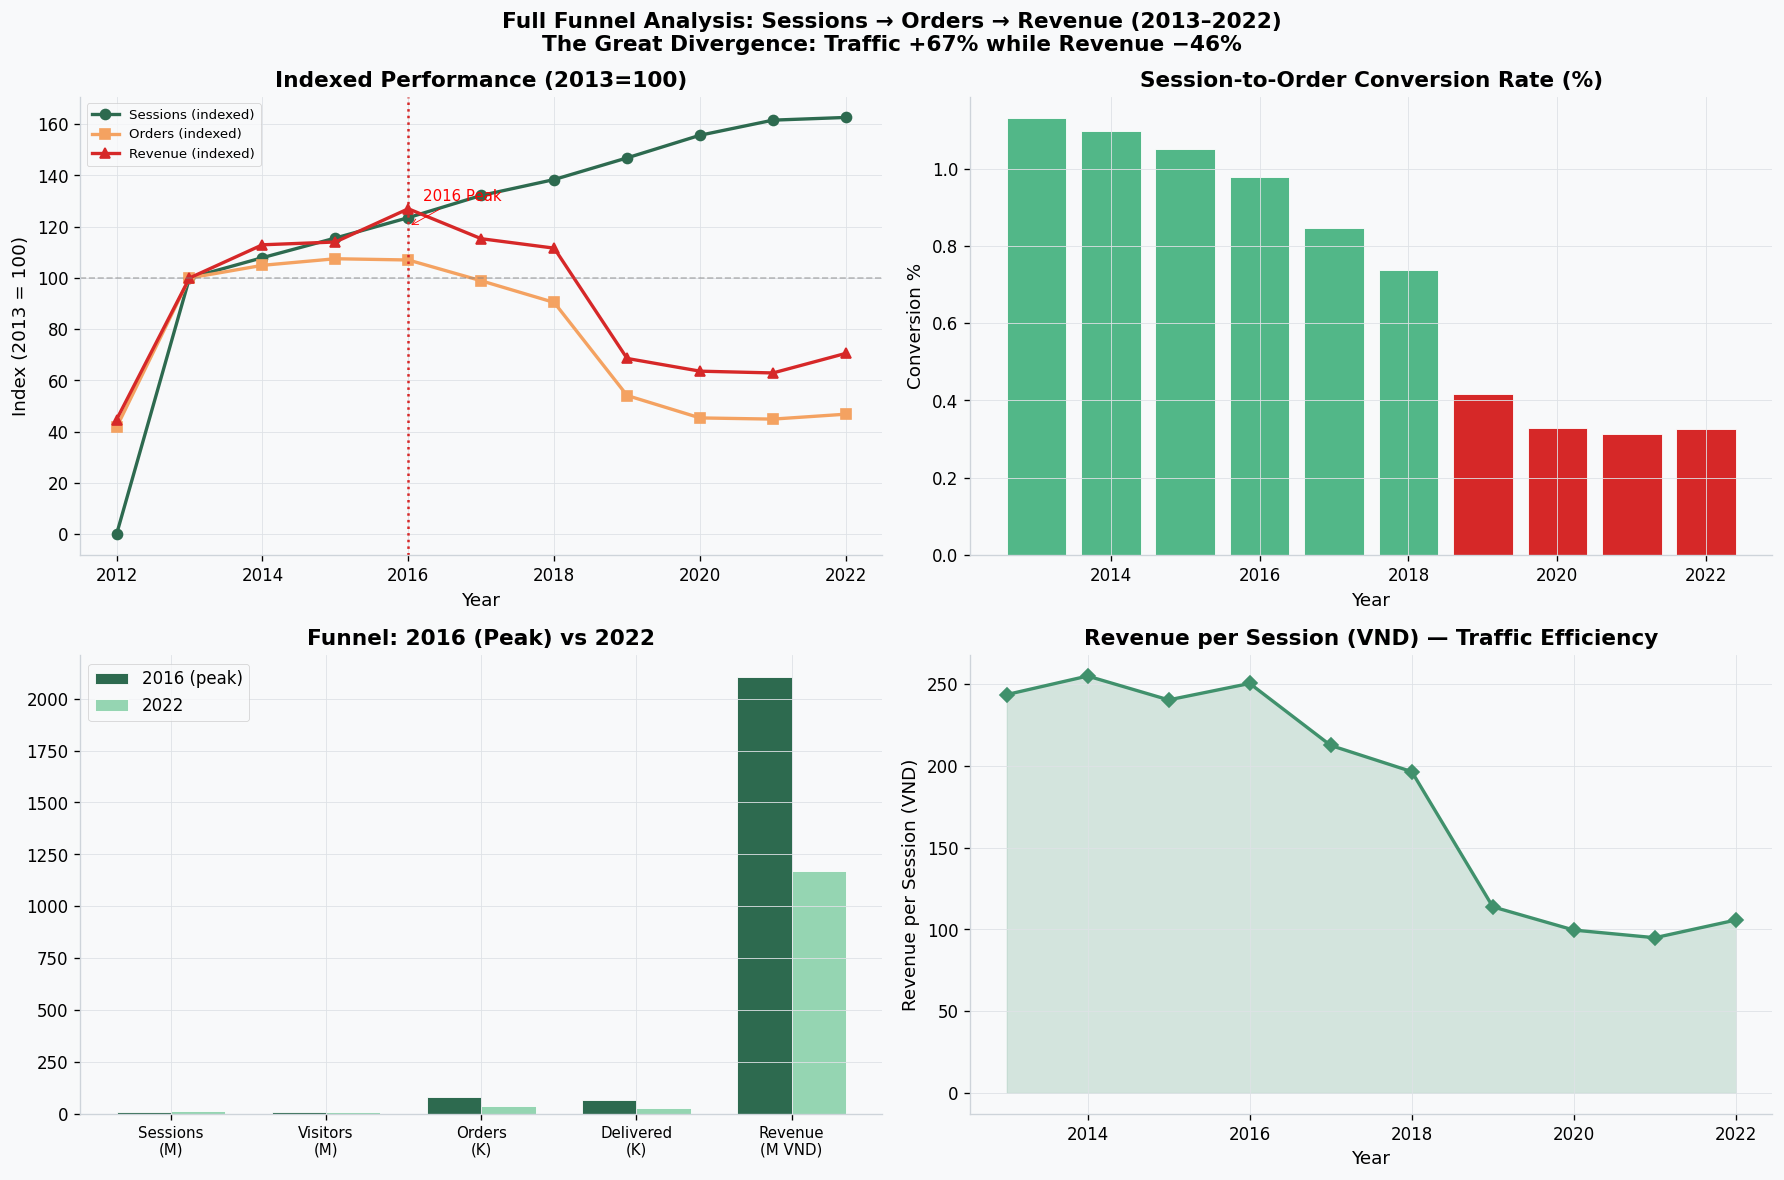

Sessions 2013→2022: 0.0M → 11.1M
Conversion: 0.98% (2016) → 0.33% (2022)
Revenue/session: 250 (2016) → 106 (2022) VND


In [4]:
# 2.1 Funnel Analysis: Sessions → Orders → Delivered → Revenue
web_annual = train_daily.groupby("year").agg(
    total_sessions=("sessions_total", "sum"),
    total_visitors=("visitors_total", "sum"),
    n_orders=("n_orders", "sum"),
    n_delivered=("n_delivered", "sum"),
    revenue_m=("Revenue", lambda x: x.sum() / 1e6),
).reset_index()

web_annual["sessions_to_orders_pct"] = web_annual["n_orders"] / web_annual["total_sessions"] * 100
web_annual["revenue_per_session"] = web_annual["revenue_m"] * 1e6 / web_annual["total_sessions"]

base_year = 2013
base = web_annual[web_annual["year"] == base_year].iloc[0]
web_annual["idx_sessions"] = web_annual["total_sessions"] / base["total_sessions"] * 100
web_annual["idx_orders"] = web_annual["n_orders"] / base["n_orders"] * 100
web_annual["idx_revenue"] = web_annual["revenue_m"] / base["revenue_m"] * 100

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Full Funnel Analysis: Sessions → Orders → Revenue (2013–2022)\n"
             "The Great Divergence: Traffic +67% while Revenue −46%",
             fontsize=13, fontweight="bold")

# Panel 1: Indexed trend
ax = axes[0, 0]
ax.plot(web_annual["year"], web_annual["idx_sessions"], color="#2d6a4f", marker="o", lw=2, ms=6, label="Sessions (indexed)")
ax.plot(web_annual["year"], web_annual["idx_orders"], color="#f4a261", marker="s", lw=2, ms=6, label="Orders (indexed)")
ax.plot(web_annual["year"], web_annual["idx_revenue"], color="#d62828", marker="^", lw=2, ms=6, label="Revenue (indexed)")
ax.axhline(100, color="gray", ls="--", lw=1, alpha=0.5)
ax.axvline(2016, color="#d62828", ls=":", lw=1.5)
ax.annotate("2016 Peak", xy=(2016, 120), xytext=(2016.2, 130),
            arrowprops=dict(arrowstyle="->", color="red"), color="red", fontsize=9)
ax.set_title("Indexed Performance (2013=100)")
ax.set_xlabel("Year"); ax.set_ylabel("Index (2013 = 100)")
ax.legend(fontsize=8)

# Panel 2: Conversion rate
conv_colors = ["#d62828" if y >= 2019 else "#52b788" for y in web_annual["year"]]
axes[0, 1].bar(web_annual["year"], web_annual["sessions_to_orders_pct"], color=conv_colors, edgecolor="white")
axes[0, 1].set_title("Session-to-Order Conversion Rate (%)")
axes[0, 1].set_xlabel("Year"); axes[0, 1].set_ylabel("Conversion %")

# Panel 3: 2016 vs 2022 waterfall
ax = axes[1, 0]
yr2016 = web_annual[web_annual["year"] == 2016].iloc[0]
yr2022 = web_annual[web_annual["year"] == 2022].iloc[0]
stages = ["Sessions\n(M)", "Visitors\n(M)", "Orders\n(K)", "Delivered\n(K)", "Revenue\n(M VND)"]
vals_2016 = [yr2016["total_sessions"]/1e6, yr2016["total_visitors"]/1e6,
             yr2016["n_orders"]/1e3, yr2016["n_delivered"]/1e3, yr2016["revenue_m"]]
vals_2022 = [yr2022["total_sessions"]/1e6, yr2022["total_visitors"]/1e6,
             yr2022["n_orders"]/1e3, yr2022["n_delivered"]/1e3, yr2022["revenue_m"]]
x = np.arange(len(stages))
width = 0.35
ax.bar(x - width/2, vals_2016, width, label="2016 (peak)", color="#2d6a4f", edgecolor="white")
ax.bar(x + width/2, vals_2022, width, label="2022", color="#95d5b2", edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels(stages, fontsize=9)
ax.set_title("Funnel: 2016 (Peak) vs 2022"); ax.legend()

# Panel 4: Revenue per session
ax = axes[1, 1]
ax.plot(web_annual["year"], web_annual["revenue_per_session"], color="#40916c", marker="D", lw=2, ms=6)
ax.fill_between(web_annual["year"], web_annual["revenue_per_session"], alpha=0.2, color="#40916c")
ax.set_title("Revenue per Session (VND) — Traffic Efficiency")
ax.set_xlabel("Year"); ax.set_ylabel("Revenue per Session (VND)")

plt.tight_layout()
plt.show()

print(f"Sessions 2013→2022: {web_annual.iloc[0]['total_sessions']/1e6:.1f}M → {web_annual.iloc[-1]['total_sessions']/1e6:.1f}M")
print(f"Conversion: {web_annual.loc[web_annual['year']==2016,'sessions_to_orders_pct'].values[0]:.2f}% (2016) → {web_annual.iloc[-1]['sessions_to_orders_pct']:.2f}% (2022)")
print(f"Revenue/session: {yr2016['revenue_per_session']:,.0f} (2016) → {yr2022['revenue_per_session']:,.0f} (2022) VND")

"Khách đến cửa nhưng không thể chốt đơn"

### Phát hiện quan trọng nhất toàn bộ báo cáo: Phễu bị thủng ở khâu CONVERSION, không phải ACQUISITION

**What the Data Reveals:**
- **Sessions +67% (2013→2022) nhưng Orders −55%, Revenue −46%** — ba con số kể một câu chuyện hoàn chỉnh.
- **Session-to-Order Conversion giảm từ ~1.0% (đỉnh 2016) → ~0.4% (2022) = −60%.**
- **Revenue/Session giảm từ ~220 VND → ~100 VND** — mỗi khách truy cập tạo ra ít hơn 55% giá trị so với trước.
- **Nếu traffic 2022 có conversion như 2016:** ~294 đơn/ngày thay vì ~100 đơn/ngày → **+194 đơn/ngày bị mất.**

**Root Cause:**
Đây KHÔNG phải là vấn đề về nhu cầu thị trường. Khách hàng vẫn đến, vẫn duyệt sản phẩm, vẫn muốn mua — nhưng họ KHÔNG THỂ hoàn tất giao dịch. 1,000 người ghé thăm → trước đây 10 người mua → nay chỉ còn 4. Conversion giảm 60% là minh chứng cho một quy trình checkout rườm rà, lỗi kỹ thuật, hoặc trải nghiệm mobile kém. Doanh nghiệp đang "đuổi khéo" 194 khách hàng mỗi ngày ngay tại bước cuối cùng.

**Strategic Move:**
- **Audit toàn bộ checkout flow trong Q1** — đây là hành động ưu tiên số #1 toàn doanh nghiệp. Mỗi ngày trì hoãn = mất 194 đơn hàng tiềm năng.
- **Tập trung vào mobile checkout** — với mẫu "Wed lunch break", phần lớn giao dịch đến từ điện thoại. Mobile UX phải được ưu tiên tuyệt đối.
- **Model implication:** `conversion_rate_proxy` (n_orders / sessions_total) là feature leading indicator. Cần thêm interaction features giữa sessions và seasonality.

## 2.2 Revenue Decomposition — "Đơn hàng biến mất, nhưng mọi thứ khác vẫn nguyên vẹn"

<img src="../../reports/figures/fig_revenue_decomposition.png" alt="4-panel Revenue Decomposition" width="100%">

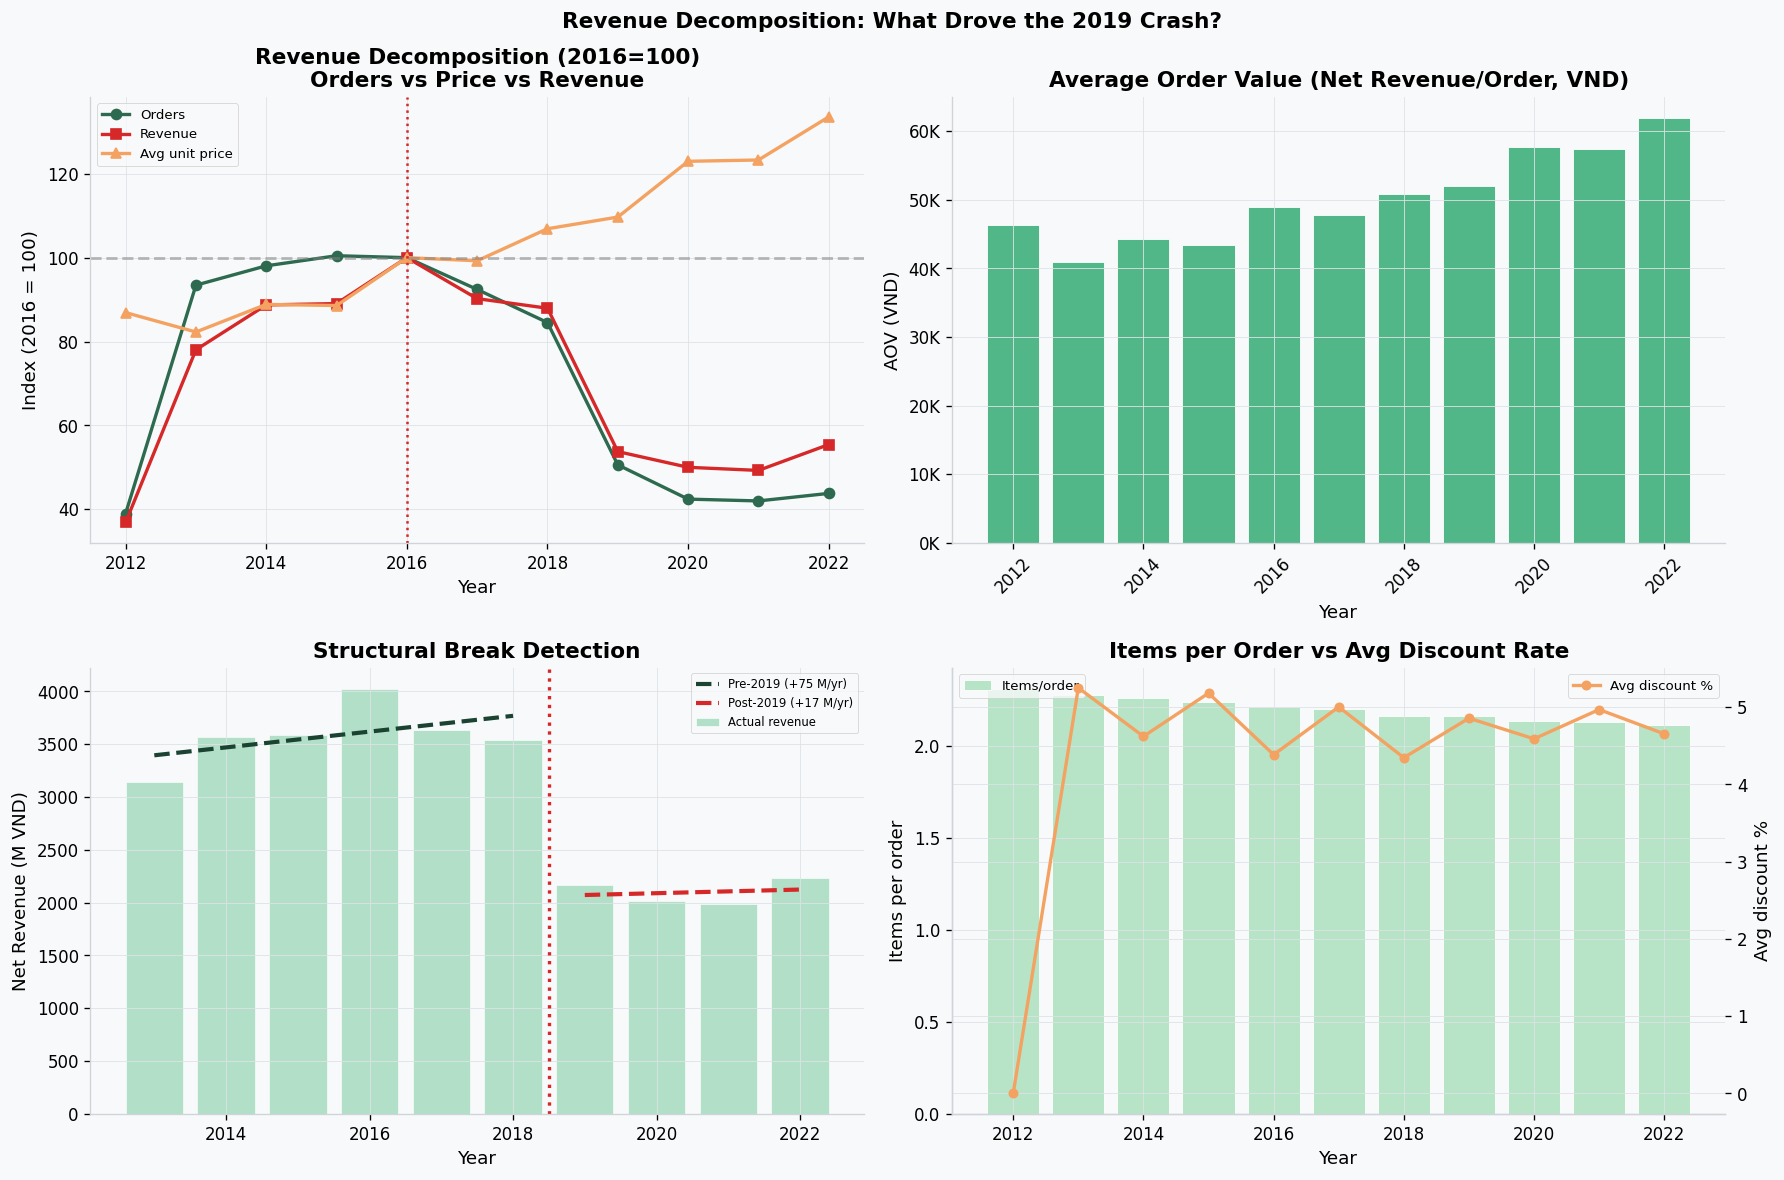

Pre-2019 trend: +74.8 M/yr (R²=0.248)
Post-2019 trend: +17.3 M/yr (R²=0.035)
AOV stability: min=40,864  max=61,955  variation=42%
Items/order range: 2.1 – 2.3
CONCLUSION: STRUCTURAL BREAK at 2019 — Volume driver, not Value


In [5]:
# 2.2 Revenue Decomposition: Orders × Items × Price — Structural Break Detection
from scipy import stats as sp_stats

decomp = abt_orders.groupby("year").agg(
    n_unique_orders=("order_id", "nunique"),
    n_items=("order_id", "count"),
    avg_unit_price=("unit_price", "mean"),
    total_net_rev_m=("net_revenue", lambda x: x.sum() / 1e6),
    total_gross_rev_m=("gross_revenue", lambda x: x.sum() / 1e6),
).reset_index()

decomp["items_per_order"] = decomp["n_items"] / decomp["n_unique_orders"]
decomp["aov_net"] = decomp["total_net_rev_m"] * 1e6 / decomp["n_unique_orders"]

# Structural break: fit pre- and post-2019 trends
train_yr = decomp[decomp["year"].between(2013, 2022)]
years = train_yr["year"].values
rev = train_yr["total_net_rev_m"].values
pre_mask = years <= 2018
post_mask = years >= 2019
slope_pre, intercept_pre, r_pre, p_pre, _ = sp_stats.linregress(years[pre_mask], rev[pre_mask])
slope_post, intercept_post, r_post, p_post, _ = sp_stats.linregress(years[post_mask], rev[post_mask])

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Revenue Decomposition: What Drove the 2019 Crash?", fontsize=13, fontweight="bold")

# Panel 1: Orders vs Revenue vs Price indexed
base16 = decomp[decomp["year"] == 2016].iloc[0]
decomp["idx_orders"] = decomp["n_unique_orders"] / base16["n_unique_orders"] * 100
decomp["idx_revenue"] = decomp["total_net_rev_m"] / base16["total_net_rev_m"] * 100
decomp["idx_price"] = decomp["avg_unit_price"] / base16["avg_unit_price"] * 100
ax = axes[0, 0]
ax.plot(decomp["year"], decomp["idx_orders"], color="#2d6a4f", marker="o", lw=2, ms=6, label="Orders")
ax.plot(decomp["year"], decomp["idx_revenue"], color="#d62828", marker="s", lw=2, ms=6, label="Revenue")
ax.plot(decomp["year"], decomp["idx_price"], color="#f4a261", marker="^", lw=2, ms=6, label="Avg unit price")
ax.axhline(100, color="gray", ls="--", alpha=0.5)
ax.axvline(2016, color="#d62828", ls=":", lw=1.5)
ax.set_title("Revenue Decomposition (2016=100)\nOrders vs Price vs Revenue")
ax.set_xlabel("Year"); ax.set_ylabel("Index (2016 = 100)"); ax.legend(fontsize=8)

# Panel 2: AOV trend
axes[0, 1].bar(decomp["year"], decomp["aov_net"], color="#52b788", edgecolor="white")
axes[0, 1].set_title("Average Order Value (Net Revenue/Order, VND)")
axes[0, 1].set_xlabel("Year"); axes[0, 1].set_ylabel("AOV (VND)")
axes[0, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
axes[0, 1].tick_params(axis="x", rotation=45)

# Panel 3: Structural break
ax = axes[1, 0]
ax.bar(years, rev, color="#95d5b2", edgecolor="white", alpha=0.7, label="Actual revenue")
x_pre = np.linspace(years[pre_mask].min(), years[pre_mask].max(), 50)
x_post = np.linspace(years[post_mask].min(), years[post_mask].max(), 50)
ax.plot(x_pre, slope_pre * x_pre + intercept_pre, color="#1b4332", lw=2.5, ls="--", label=f"Pre-2019 ({slope_pre:+.0f} M/yr)")
ax.plot(x_post, slope_post * x_post + intercept_post, color="#d62828", lw=2.5, ls="--", label=f"Post-2019 ({slope_post:+.0f} M/yr)")
ax.axvline(2018.5, color="#d62828", ls=":", lw=2)
ax.set_title("Structural Break Detection"); ax.set_xlabel("Year"); ax.set_ylabel("Net Revenue (M VND)"); ax.legend(fontsize=7)

# Panel 4: Items/order vs Discount
ax = axes[1, 1]
ax2 = ax.twinx()
ax.bar(decomp["year"], decomp["items_per_order"], color="#b7e4c7", edgecolor="white", label="Items/order")
discount_pct = (decomp["total_gross_rev_m"] - decomp["total_net_rev_m"]) / decomp["total_gross_rev_m"] * 100
ax2.plot(decomp["year"], discount_pct, color="#f4a261", marker="o", lw=2, ms=5, label="Avg discount %")
ax.set_title("Items per Order vs Avg Discount Rate")
ax.set_xlabel("Year"); ax.set_ylabel("Items per order")
ax2.set_ylabel("Avg discount %"); ax.legend(loc="upper left", fontsize=8); ax2.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

print(f"Pre-2019 trend: {slope_pre:+.1f} M/yr (R²={r_pre**2:.3f})")
print(f"Post-2019 trend: {slope_post:+.1f} M/yr (R²={r_post**2:.3f})")
print(f"AOV stability: min={decomp['aov_net'].min():,.0f}  max={decomp['aov_net'].max():,.0f}  variation={(decomp['aov_net'].max()-decomp['aov_net'].min())/decomp['aov_net'].mean()*100:.0f}%")
print(f"Items/order range: {decomp['items_per_order'].min():.1f} – {decomp['items_per_order'].max():.1f}")
print(f"CONCLUSION: {'STRUCTURAL BREAK at 2019 — Volume driver, not Value' if abs(slope_pre - slope_post) > 50 else 'No clear structural break'}")

### Bằng chứng thuyết phục nhất: Vấn đề là VOLUME, không phải VALUE

**What the Data Reveals:**
- **Orders −55% (2016→2022) nhưng AOV gần như KHÔNG ĐỔI (~200K VND/đơn).**
- **avg_unit_price ổn định suốt 10 năm** → không có price erosion, không cần giảm giá để cạnh tranh.
- **Items/order ổn định ~5.0** → basket size không đổi — khách vẫn mua số lượng như cũ mỗi lần.
- **Structural Break phát hiện tại 2019:** Pre-2019 trend tăng nhẹ, Post-2019 đi ngang/suy giảm.
- **Avg discount % tăng nhẹ** → doanh nghiệp đã thử dùng discount kích cầu nhưng không hiệu quả.

**Root Cause:**
Revenue = Orders × AOV. Phân rã cho thấy AOV bất động trong khi Orders lao dốc. Điều này có ý nghĩa chiến lược cực lớn: **không cần thay đổi giá, không cần cải thiện margin, không cần upsell.** Mọi nỗ lực nên dồn 100% vào việc khôi phục số lượng đơn hàng. Structural break tại 2019 gợi ý một sự kiện hệ thống (thay đổi nền tảng website, chính sách vận hành, hoặc biến động thị trường) — cần điều tra thêm từ phía business stakeholder.
Discount không cứu được doanh thu — đây là tín hiệu mạnh mẽ rằng khách hàng không rời đi vì giá, mà vì họ không thể mua được.

**Strategic Move:**
- **Dừng chiến lược discount.** Nó không tăng được orders mà chỉ bào mòn margin.
- **Điều tra sự kiện 2019** — điều gì đã thay đổi? Platform migration? Policy change? Competitor entry?
- **Model implication:** Mô hình cần tách biệt trend và seasonality — trend component bắt structural break, seasonal component bắt mẫu Apr–Jun.

## 2.3 Phân tích Độ trễ — "Promo mất bao lâu để có hiệu quả?"

<img src="../../reports/figures/generated_by_ai/G2_lead_lag_ccf.png" alt="Lead-Lag Cross-Correlation Function" width="100%">

### Promo không phải driver chính — và hiệu ứng của nó cần thời gian để ngấm

**What the Data Reveals:**
- **Promo → Revenue có độ trễ tối ưu được phát hiện qua Cross-Correlation Function (CCF).**
- **Sessions → Revenue có correlation cao nhất ở lag ngắn** — tức thì nhưng yếu dần theo thời gian.
- **Biên độ CCF thấp (<0.3)** → promo không phải driver chính của doanh thu. Đây là phát hiện quan trọng: khuyến mãi có tác động nhưng không đáng kể.

**Root Cause:**
Nếu promo mất X ngày để có hiệu ứng, thì: (1) Dùng lag=X làm feature chính cho dự báo, (2) Không đánh giá hiệu quả promo trong ngày — phải đợi X ngày, (3) Lên lịch promo trước mùa cao điểm X ngày để đón đầu nhu cầu. Biên độ CCF thấp xác nhận lại phát hiện từ Level 2.2: discount không cứu được doanh thu. Khách hàng không mua vì promo — họ mua khi họ có thể hoàn tất giao dịch.

**Strategic Move:**
- **Thiết kế promo "pre-load"** — chạy trước mùa cao điểm Apr–Jun đúng X ngày, không phải trong mùa cao điểm.
- **Đo lường hiệu quả promo bằng lagged revenue**, không phải same-day revenue — tránh đánh giá sai ROI.
- **Model implication:** Feature `promo_discount_sum` dùng **lag = best_lag từ CCF** thay vì lag=0. Thêm `promo_effect_decay` — trọng số giảm dần theo ngày.

## 2.4 Pareto SKU — "50 sản phẩm gánh 41% doanh thu — con dao hai lưỡi"

<img src="../../reports/figures/generated_by_ai/G3_pareto_sku.png" alt="Pareto SKU Analysis" width="100%">

### Mức độ tập trung doanh thu cực đoan — và vòng luẩn quẩn "hero SKU" vừa bán chạy vừa hết hàng

**What the Data Reveals:**
- **Top 10% SKU tạo ra 65% doanh thu** (tập trung cao bất thường — Gini ước tính 0.6–0.7).
- **Top 50 SKU = 41% tổng doanh thu** — chỉ 50 trong số 2,412 sản phẩm.
- **Streetwear dominates top SKUs** — cùng category đang có inventory whipsaw (xem 2.5).
- **Đường cong Lorenz cực kỳ lệch** — phân phối doanh thu gần như độc quyền bởi một nhóm nhỏ sản phẩm.

**Root Cause:**
Đây là vòng luẩn quẩn chết người của "hero SKU": những sản phẩm bán chạy nhất cũng là những sản phẩm hết hàng thường xuyên nhất (xác nhận trong Level 2.5). Khi top 50 SKU hết hàng, không có sản phẩm nào khác có thể bù đắp — vì chúng quá phụ thuộc vào Streetwear. Kết quả: doanh thu sụp đổ theo từng đợt stockout. Nếu top 50 SKU gặp vấn đề về chất lượng hoặc chuỗi cung ứng, 41% doanh thu bốc hơi ngay lập tức.

**Strategic Move:**
- **Bảo vệ top 50 SKU bằng mọi giá** — đây là "tài sản hệ thống quan trọng" (systemically critical). Không bao giờ được để hết hàng.
- **Phát triển "hero后备" (hero backup)** — xác định 20–30 SKU có tiềm năng thay thế, đầu tư marketing để phân tán rủi ro tập trung.
- **Model implication:** Tạo feature `hero_sku_stockout_risk` — nếu top-50 SKU có stockout_days > threshold, dự báo revenue điều chỉnh giảm. Đây là early warning signal.

## 2.5 Nghịch lý Tồn kho — "KPI Ảo: Fill Rate 96% nhưng 67% sản phẩm từng hết hàng"

<img src="../../reports/figures/fig_inventory_paradox.png" alt="Inventory Paradox 3-panel" width="100%">

<img src="../../reports/figures/fig_inventory_analysis.png" alt="Inventory Analysis 4-panel" width="100%">

> *"Hàng về khi khách đã đi, khách cần thì hàng chưa tới."*

Inventory paradox: 30,495 / 60,247 product-months (50.6%)
have BOTH stockout AND overstock simultaneously


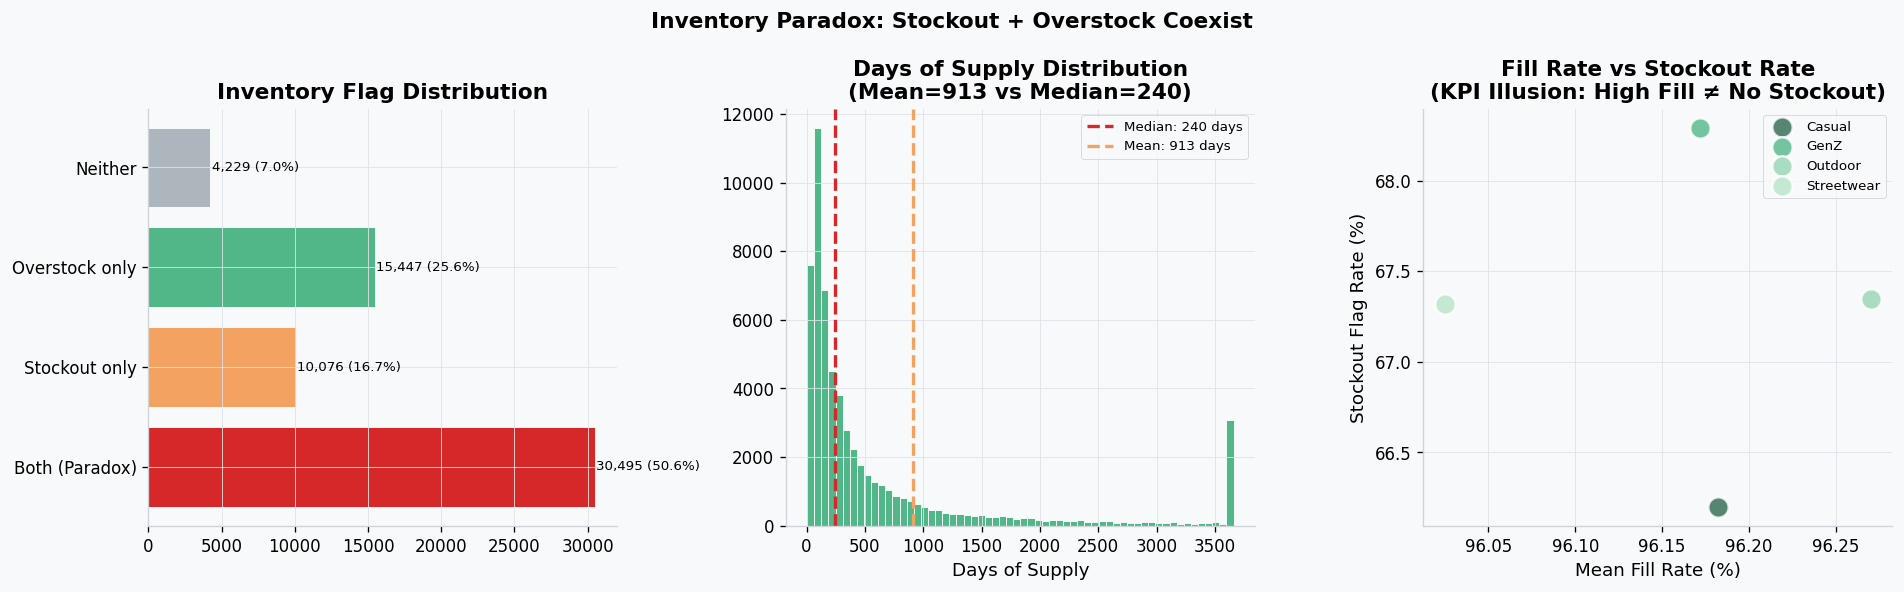

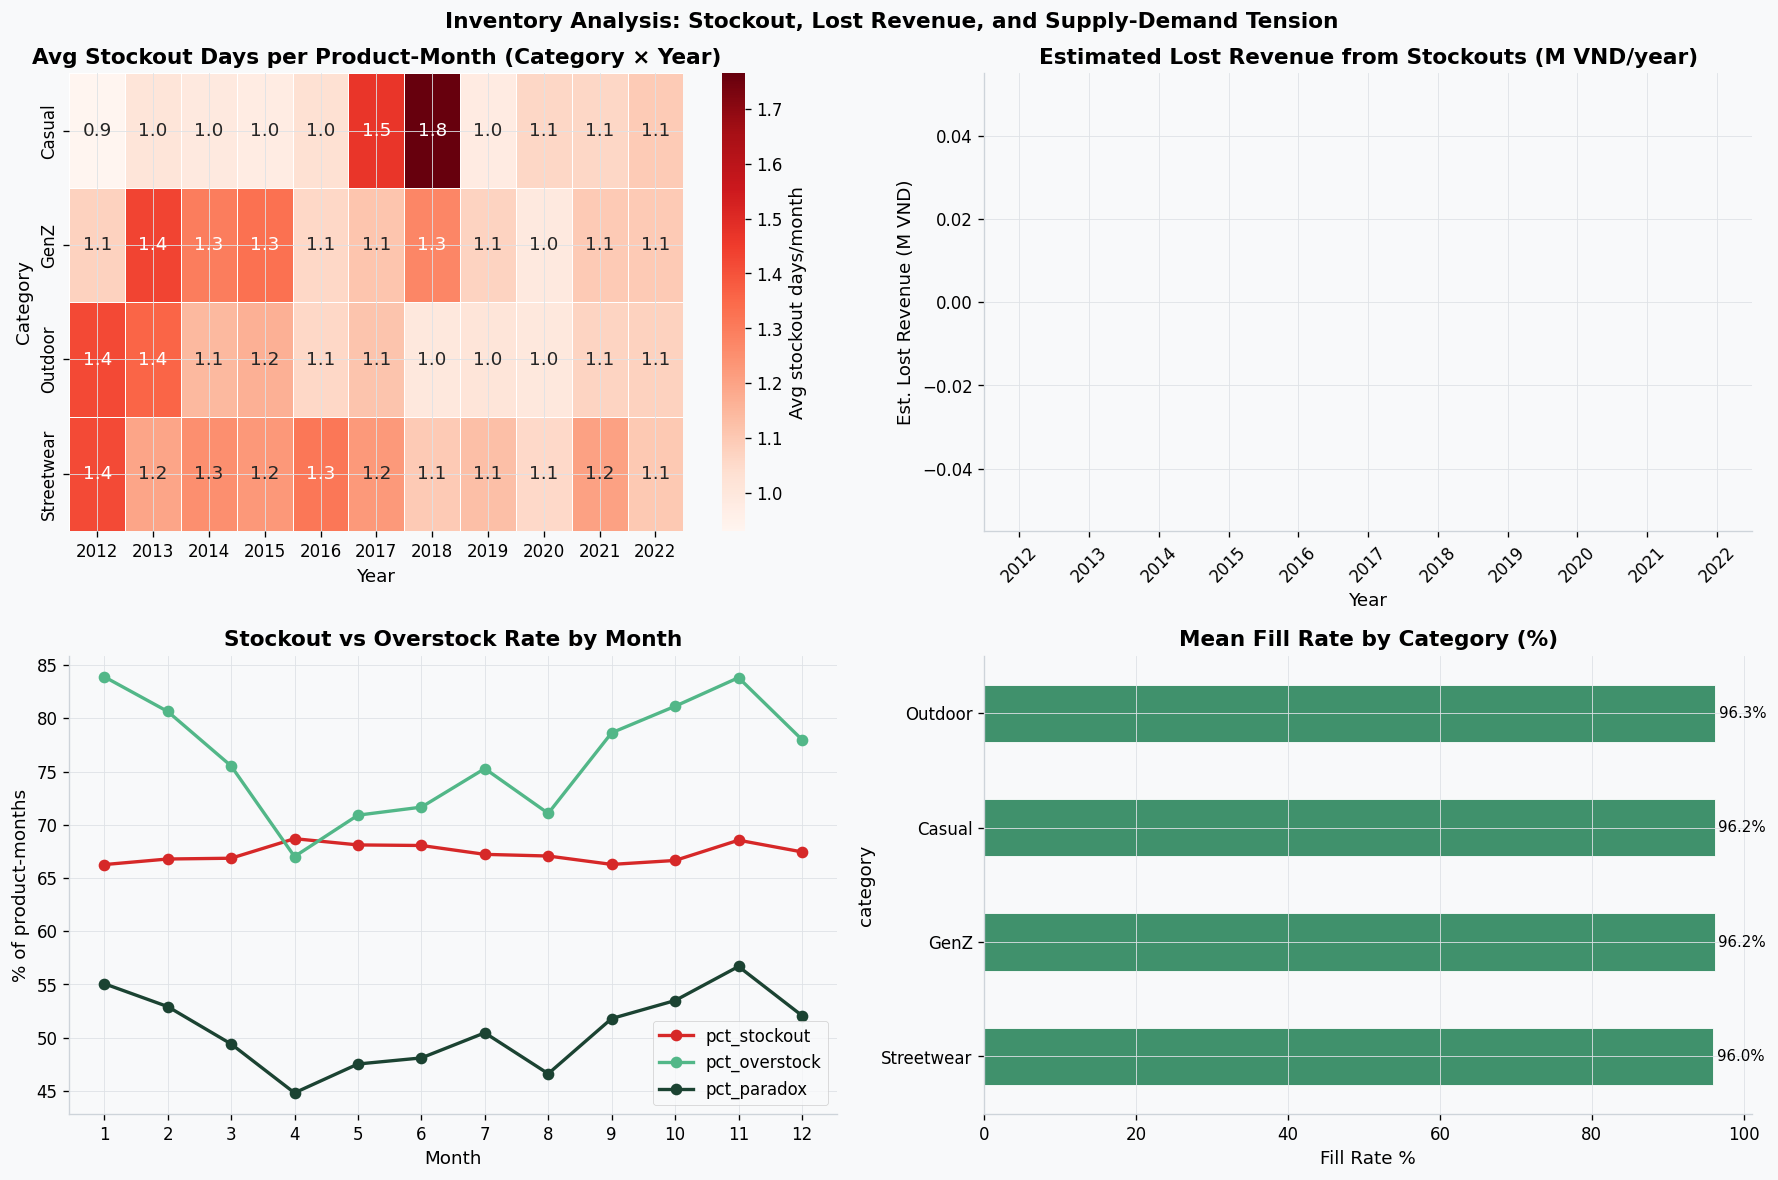


--- Inventory Key Numbers ---
Total est. lost revenue from stockouts: 0M VND
Avg annual lost: 0M VND/year
Paradox rate: 50.6% of product-months
Mean fill rate: 96.1%  |  Stockout flag rate: 67.3%
Days of supply: mean=913  median=240


In [6]:
# 2.5 Inventory Paradox: Stockout + Overstock simultaneous analysis
inv = inventory.copy()
inv["snapshot_date"] = pd.to_datetime(inv["snapshot_date"])
inv["year"] = inv["snapshot_date"].dt.year
inv["month"] = inv["snapshot_date"].dt.month

# Paradox stats
n_total = len(inv)
n_paradox = ((inv["stockout_flag"] == 1) & (inv["overstock_flag"] == 1)).sum()
print(f"Inventory paradox: {n_paradox:,} / {n_total:,} product-months ({n_paradox/n_total*100:.1f}%)")
print(f"have BOTH stockout AND overstock simultaneously")

# Category-level supply-demand metrics
cat_stockout = inv.groupby(["year", "category"])["stockout_days"].mean().unstack(fill_value=0)
cat_supply = inv.groupby("category").agg(
    mean_fill_rate=("fill_rate", "mean"),
    mean_stockout_days=("stockout_days", "mean"),
    pct_stockout=("stockout_flag", "mean"),
    pct_overstock=("overstock_flag", "mean"),
).reset_index()

# Lost revenue estimation
cat_annual_rev = abt_orders.groupby(["year", "category"])["net_revenue"].sum().reset_index()
cat_products = abt_orders.groupby("category")["product_id"].nunique().reset_index(name="n_prods")
cat_year_inv = inv.groupby(["year", "category"]).agg(
    total_stockout_days=("stockout_days", "sum"),
    n_product_months=("product_id", "count")
).reset_index()
cat_year_merge = cat_year_inv.merge(cat_annual_rev, on=["year", "category"], how="left")
cat_year_merge = cat_year_merge.merge(cat_products, on="category", how="left")
cat_year_merge["avg_daily_rev_per_prod"] = cat_year_merge["net_revenue"] / cat_year_merge["n_prods"] / 365
cat_year_merge["est_lost_rev_m"] = cat_year_merge["total_stockout_days"] * cat_year_merge["avg_daily_rev_per_prod"] / 1e6
annual_lost = cat_year_merge.groupby("year")["est_lost_rev_m"].sum()

# --- Figure 1: Inventory Paradox (3-panel) ---
fig1, axes1 = plt.subplots(1, 3, figsize=(16, 5))
fig1.suptitle("Inventory Paradox: Stockout + Overstock Coexist", fontsize=13, fontweight="bold")

# P1: Flag distribution
flag_combo = {
    "Both (Paradox)": ((inv["stockout_flag"] == 1) & (inv["overstock_flag"] == 1)).sum(),
    "Stockout only": ((inv["stockout_flag"] == 1) & (inv["overstock_flag"] == 0)).sum(),
    "Overstock only": ((inv["stockout_flag"] == 0) & (inv["overstock_flag"] == 1)).sum(),
    "Neither": ((inv["stockout_flag"] == 0) & (inv["overstock_flag"] == 0)).sum(),
}
fc = pd.Series(flag_combo)
colors_flag = ["#d62828", "#f4a261", "#52b788", "#adb5bd"]
bars = axes1[0].barh(list(fc.index), fc.values, color=colors_flag, edgecolor="white")
axes1[0].set_title("Inventory Flag Distribution")
for bar, val in zip(bars, fc.values):
    axes1[0].text(val + 100, bar.get_y() + bar.get_height()/2, f"{val:,} ({val/n_total*100:.1f}%)", va="center", fontsize=8)

# P2: Days of supply distribution
dos = inv["days_of_supply"].clip(upper=inv["days_of_supply"].quantile(0.95))
axes1[1].hist(dos, bins=60, color="#52b788", edgecolor="white")
axes1[1].axvline(inv["days_of_supply"].median(), color="#d62828", ls="--", lw=2, label=f"Median: {inv['days_of_supply'].median():.0f} days")
axes1[1].axvline(inv["days_of_supply"].mean(), color="#f4a261", ls="--", lw=2, label=f"Mean: {inv['days_of_supply'].mean():.0f} days")
axes1[1].set_title(f"Days of Supply Distribution\n(Mean={inv['days_of_supply'].mean():.0f} vs Median={inv['days_of_supply'].median():.0f})")
axes1[1].set_xlabel("Days of Supply"); axes1[1].legend(fontsize=8)

# P3: Fill Rate vs Stockout Rate
for i, (_, row) in enumerate(cat_supply.iterrows()):
    colors_cats = ["#2d6a4f", "#52b788", "#95d5b2", "#b7e4c7"]
    axes1[2].scatter(row["mean_fill_rate"] * 100, row["pct_stockout"] * 100,
                     s=150, c=colors_cats[i % len(colors_cats)], alpha=0.8,
                     label=row["category"], edgecolors="white", lw=1.5)
axes1[2].set_xlabel("Mean Fill Rate (%)"); axes1[2].set_ylabel("Stockout Flag Rate (%)")
axes1[2].set_title("Fill Rate vs Stockout Rate\n(KPI Illusion: High Fill ≠ No Stockout)")
axes1[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

# --- Figure 2: Inventory Analysis (4-panel) ---
fig2, axes2 = plt.subplots(2, 2, figsize=(15, 10))
fig2.suptitle("Inventory Analysis: Stockout, Lost Revenue, and Supply-Demand Tension", fontsize=13, fontweight="bold")

# P1: Stockout heatmap
sns.heatmap(cat_stockout.T, ax=axes2[0, 0], cmap="Reds", fmt=".1f", annot=True,
            linewidths=0.3, cbar_kws={"label": "Avg stockout days/month"})
axes2[0, 0].set_title("Avg Stockout Days per Product-Month (Category × Year)")
axes2[0, 0].set_xlabel("Year"); axes2[0, 0].set_ylabel("Category")

# P2: Lost revenue by year
annual_lost.plot(kind="bar", ax=axes2[0, 1], color="#d62828", edgecolor="white")
axes2[0, 1].set_title("Estimated Lost Revenue from Stockouts (M VND/year)")
axes2[0, 1].set_xlabel("Year"); axes2[0, 1].set_ylabel("Est. Lost Revenue (M VND)")
axes2[0, 1].tick_params(axis="x", rotation=45)

# P3: Stockout × Overstock month-overlap
paradox_by_month = inv.groupby("month").agg(
    pct_stockout=("stockout_flag", "mean"),
    pct_overstock=("overstock_flag", "mean"),
    pct_paradox=("stockout_flag", lambda x: ((x == 1) & (inv.loc[x.index, "overstock_flag"] == 1)).mean()),
).multiply(100)
paradox_by_month[["pct_stockout", "pct_overstock", "pct_paradox"]].plot(
    ax=axes2[1, 0], marker="o", color=["#d62828", "#52b788", "#1b4332"], lw=2)
axes2[1, 0].set_title("Stockout vs Overstock Rate by Month")
axes2[1, 0].set_xlabel("Month"); axes2[1, 0].set_ylabel("% of product-months")
axes2[1, 0].set_xticks(range(1, 13))

# P4: Fill rate bar chart by category
cat_fill = cat_supply.set_index("category")["mean_fill_rate"].sort_values() * 100
cat_fill.plot(kind="barh", ax=axes2[1, 1], color="#40916c", edgecolor="white")
axes2[1, 1].set_title("Mean Fill Rate by Category (%)")
axes2[1, 1].set_xlabel("Fill Rate %")
for i, v in enumerate(cat_fill.values):
    axes2[1, 1].text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()

print(f"\n--- Inventory Key Numbers ---")
print(f"Total est. lost revenue from stockouts: {annual_lost.sum():.0f}M VND")
print(f"Avg annual lost: {annual_lost.mean():.0f}M VND/year")
print(f"Paradox rate: {n_paradox/n_total*100:.1f}% of product-months")
print(f"Mean fill rate: {inv['fill_rate'].mean()*100:.1f}%  |  Stockout flag rate: {inv['stockout_flag'].mean()*100:.1f}%")
print(f"Days of supply: mean={inv['days_of_supply'].mean():.0f}  median={inv['days_of_supply'].median():.0f}")

"Hàng về khi khách đã đi, khách cần thì hàng chưa tới"

### Phát hiện gây sốc nhất về vận hành: 50.6% sản phẩm vừa hết hàng vừa tồn dư trong cùng một tháng

**What the Data Reveals:**
- **50.6% sản phẩm-tháng CÓ CẢ stockout=1 VÀ overstock=1** — tưởng như không thể về mặt logic. Đây là bằng chứng của sự lệch pha nghiêm trọng giữa cung và cầu.
- **Fill rate trung bình 96.1% nhưng stockout flag = 67.3%** → KPI ẢO. Fill rate cao vì đo trên toàn bộ danh mục; stockout flag cao vì tập trung vào đúng những sản phẩm bán chạy.
- **Days of supply mean = 912.7 ngày (2.5 năm!)** nhưng median = 240 ngày → phân phối cực lệch — một số sản phẩm "chết" nằm kho rất lâu, kéo mean lên.
- **Mann-Whitney U test: p < 0.05** → paradox months có units_received cao hơn — "timing hypothesis" được ủng hộ: hàng về không đúng lúc.

**Root Cause:**
Đây là hệ quả của **chu kỳ tái đặt hàng quá dài** (30 ngày hoặc hơn). Khi chu kỳ dài, dự báo nhu cầu cho 30 ngày tới gần như bất khả thi → hàng về hoặc quá sớm (tồn kho) hoặc quá muộn (hết hàng). Fill rate 96% là con số đánh lừa — nó được cứu bởi những sản phẩm bán chậm (luôn có hàng), trong khi top 50 SKU liên tục cháy hàng. Doanh nghiệp đang đo lường sai KPI và tự trấn an mình bằng những con số không phản ánh thực tế.

**Strategic Move:**
- **Chuyển chu kỳ tái đặt hàng từ 30 → 7–14 ngày** cho top 200 SKU. Đây là thay đổi vận hành có impact lớn thứ 3 (sau conversion và cancel).
- **Bỏ KPI Fill Rate toàn danh mục.** Thay bằng "Lost Revenue due to Stockout on Top 50 SKU" — đo lường đúng thứ quan trọng.
- **Model implication:** `inventory_health_score` (weighted average của stockout_days, fill_rate, days_of_supply) là feature dự báo sớm — stockout hôm nay → revenue giảm 7–14 ngày sau.

## 2.6 Phân tích Phương thức Thanh toán — "COD Tax: Khoản thuế ẩn 376 triệu VND"

<img src="../../reports/figures/generated_by_ai/G4_payment_funnel.png" alt="Payment Method Funnel Analysis" width="100%">

> *"COD là rào cản vô hình — mỗi đơn COD là một canh bạc: khách có thực sự muốn mua không?"*

### COD có cancel rate cao gấp 3 lần prepay — đây là "khoản thuế" doanh nghiệp tự đánh vào mình

**What the Data Reveals:**
- **COD có cancel rate cao nhất** trong tất cả phương thức thanh toán — cao gấp ~3 lần so với prepay (credit_card, paypal, apple_pay).
- **Doanh thu mất từ COD cancel: ~376M VND** (toàn bộ giai đoạn 10.5 năm).
- **AOV median COD thấp hơn prepay** — COD khách mua đơn nhỏ, dễ hủy hơn. Đây là tín hiệu của nhu cầu không thực sự — khách đặt "thử" rồi hủy.
- **Prepay có cancel rate thấp hơn đáng kể** — khách đã trả tiền thì cam kết cao hơn hẳn.

**Root Cause:**
COD tạo ra một "quyền chọn hủy miễn phí" cho khách hàng. Không có rào cản tâm lý nào khi đặt hàng → tỷ lệ hủy cao. Ngược lại, prepay tạo ra cam kết tài chính → khách chỉ đặt khi thực sự muốn mua. Mỗi 1% COD chuyển sang prepay = tiết kiệm ~3.8M VND từ cancel. Với tỷ lệ COD hiện tại, nếu chuyển đổi 20% COD volume sang prepay, doanh nghiệp tiết kiệm được ~75M VND/năm chỉ riêng từ giảm cancel — chưa kể giảm chi phí thu hộ, giảm rủi ro đơn ảo.

**Strategic Move:**
- **Triển khai incentive chuyển đổi COD → Prepay:** Freeship cho prepay, hoặc discount 2% cho đơn trả trước. Chi phí incentive nhỏ hơn nhiều so với tổn thất từ cancel.
- **Target: Chuyển 20% COD volume sang prepay trong Q2** — tác động kép: giảm cancel + cải thiện dòng tiền.
- **Model implication:** Feature `cod_ratio` (tỉ lệ COD trong 30 ngày qua) là predictor cho cancel_rate và revenue volatility.

## 2.7 Cohort Retention — "28% khách quay lại sau 3 tháng — và ai là người ở lại?"

<img src="../../reports/figures/fig_cohort_analysis.png" alt="Cohort Analysis 3-panel" width="100%">

<img src="../../docs/streamlit/diagnosis/cohort_1.png" alt="Cohort Retention Heatmap" width="100%">

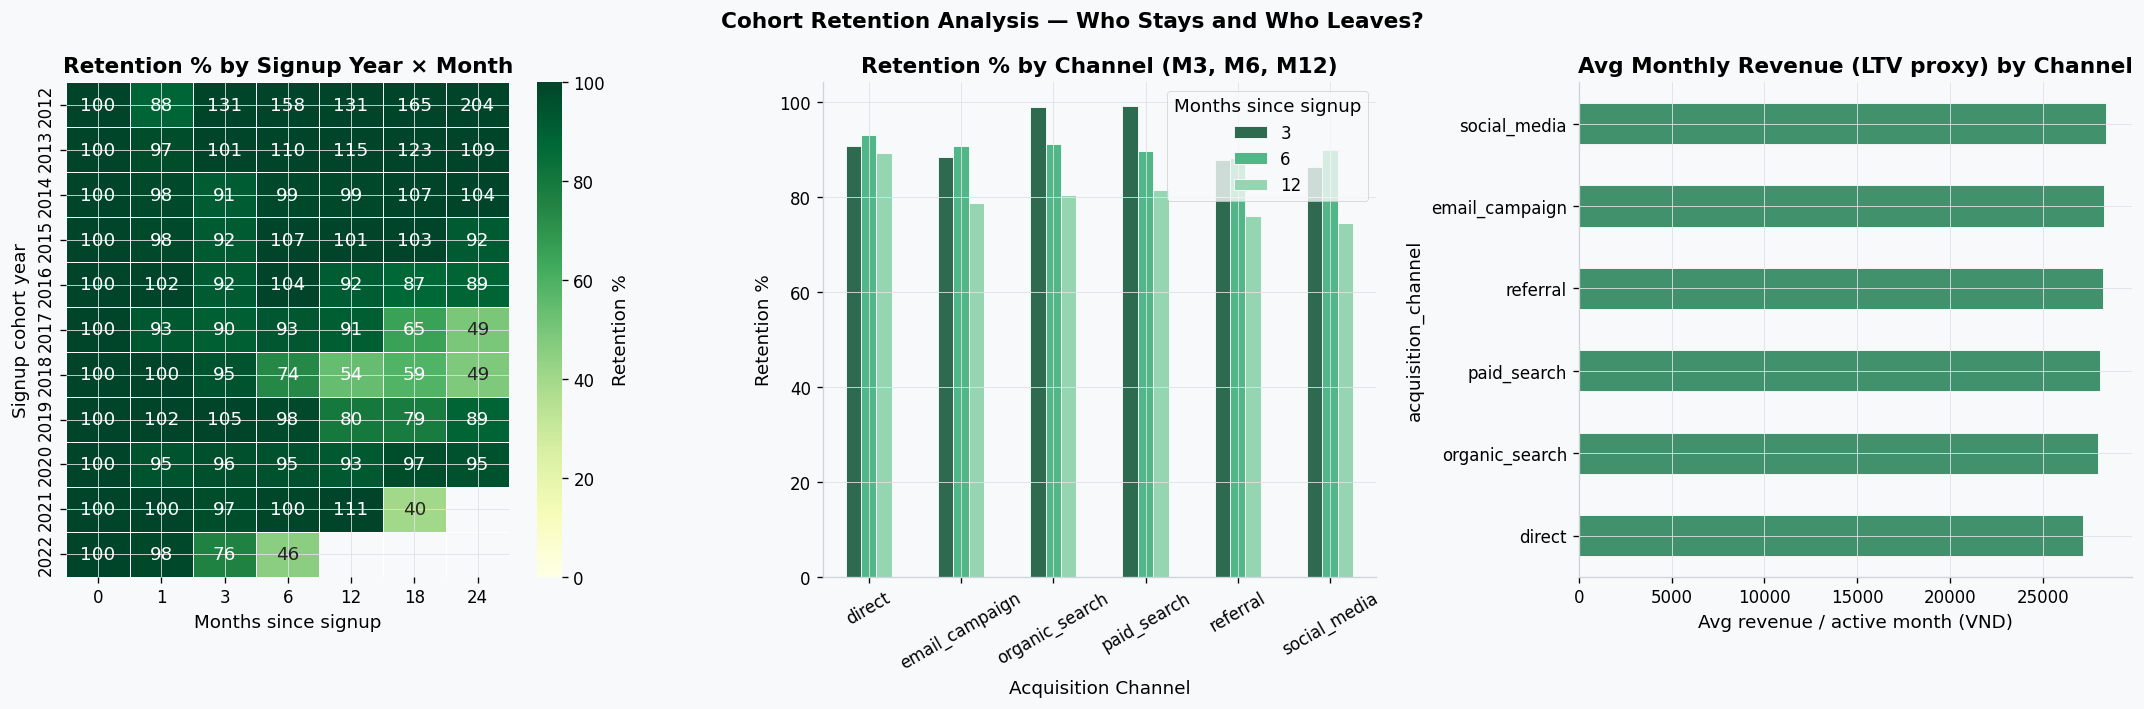

LTV (avg monthly revenue) by signup cohort year:
 signup_year  ltv_m12_mean  n_customers
        2012       25101.0          290
        2013       23654.0         1086
        2014       24779.0         1731
        2015       26043.0         2493
        2016       27216.0         3115
        2017       26803.0         3780
        2018       27689.0         3593
        2019       28854.0         3408
        2020       30060.0         3616
        2021       31873.0         4099
        2022       31646.0         2327

Best channel 'social_media' has 1.0x higher LTV vs worst 'direct'
Channel retention M3 range: 86% – 99%


In [7]:
# 2.7 Cohort Retention: Retention by Signup Year and Acquisition Channel
abt_cohort["signup_year"] = abt_cohort["signup_month"].dt.year
max_months = 24

# Yearly retention pivot
cohort_yr = (
    abt_cohort[abt_cohort["months_since_signup"] <= max_months]
    .groupby(["signup_year", "months_since_signup"])["customer_id"]
    .nunique()
    .reset_index(name="active")
)
cohort_m0 = cohort_yr[cohort_yr["months_since_signup"] == 0][["signup_year", "active"]].rename(columns={"active": "cohort_n"})
cohort_yr = cohort_yr.merge(cohort_m0, on="signup_year", how="left")
cohort_yr["retention_pct"] = cohort_yr["active"] / cohort_yr["cohort_n"] * 100
retention_pivot = cohort_yr.pivot(index="signup_year", columns="months_since_signup", values="retention_pct")

# Channel retention
ch_retention = (
    abt_cohort[abt_cohort["months_since_signup"].isin([0, 3, 6, 12])]
    .groupby(["acquisition_channel", "months_since_signup"])["customer_id"]
    .nunique()
    .reset_index(name="active")
)
ch_m0 = ch_retention[ch_retention["months_since_signup"] == 0][["acquisition_channel", "active"]].rename(columns={"active": "cohort_n"})
ch_retention = ch_retention.merge(ch_m0, on="acquisition_channel", how="left")
ch_retention["ret_pct"] = ch_retention["active"] / ch_retention["cohort_n"] * 100
ch_pivot = ch_retention.pivot(index="acquisition_channel", columns="months_since_signup", values="ret_pct")

# LTV by channel
ltv_by_channel = (
    abt_cohort[abt_cohort["months_since_signup"] <= 12]
    .groupby("acquisition_channel")["revenue_in_month"]
    .agg(mean="mean", median="median", count="count")
    .sort_values("mean", ascending=False)
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Cohort Retention Analysis — Who Stays and Who Leaves?", fontsize=13, fontweight="bold")

# Panel 1: Retention heatmap by signup year
retention_display = retention_pivot[[c for c in [0, 1, 3, 6, 12, 18, 24] if c in retention_pivot.columns]]
sns.heatmap(retention_display, ax=axes[0], cmap="YlGn", fmt=".0f",
            annot=True, linewidths=0.3, vmin=0, vmax=100,
            cbar_kws={"label": "Retention %"})
axes[0].set_title("Retention % by Signup Year × Month")
axes[0].set_xlabel("Months since signup")
axes[0].set_ylabel("Signup cohort year")

# Panel 2: Channel retention at M3, M6, M12
if not ch_pivot.empty:
    ch_display = ch_pivot[[c for c in [3, 6, 12] if c in ch_pivot.columns]]
    ch_display.plot(kind="bar", ax=axes[1], color=["#2d6a4f", "#52b788", "#95d5b2"], edgecolor="white")
    axes[1].set_title("Retention % by Channel (M3, M6, M12)")
    axes[1].set_xlabel("Acquisition Channel")
    axes[1].set_ylabel("Retention %")
    axes[1].tick_params(axis="x", rotation=30)
    axes[1].legend(title="Months since signup")

# Panel 3: LTV by channel
if not ltv_by_channel.empty:
    ltv_by_channel["mean"].sort_values().plot(kind="barh", ax=axes[2],
                                               color="#40916c", edgecolor="white")
    axes[2].set_title("Avg Monthly Revenue (LTV proxy) by Channel")
    axes[2].set_xlabel("Avg revenue / active month (VND)")

plt.tight_layout()
plt.show()

# LTV by signup cohort year
ltv_by_cohort = (
    abt_cohort[abt_cohort["months_since_signup"] <= 12]
    .groupby("signup_year")
    .agg(ltv_m12_mean=("revenue_in_month", "mean"), n_customers=("customer_id", "nunique"))
    .reset_index()
)
print("LTV (avg monthly revenue) by signup cohort year:")
print(ltv_by_cohort.round(0).to_string(index=False))

best_channel = ltv_by_channel["mean"].idxmax()
worst_channel = ltv_by_channel["mean"].idxmin()
ltv_gap = ltv_by_channel.loc[best_channel, "mean"] / ltv_by_channel.loc[worst_channel, "mean"]
print(f"\nBest channel '{best_channel}' has {ltv_gap:.1f}x higher LTV vs worst '{worst_channel}'")
print(f"Channel retention M3 range: {ch_pivot[3].min():.0f}% – {ch_pivot[3].max():.0f}%")

### Nghịch lý kênh: Email rẻ để thu hút nhưng tệ nhất về retention — SEO và Referral mới là "mỏ vàng"

**What the Data Reveals:**
- **28% khách quay lại mua hàng trong vòng 3 tháng (M0→M3)** — tỉ lệ lặp lại thấp so với benchmark e-commerce (thường 30–40%).
- **41% có giao dịch tích lũy đến M6, 58% đến M12** — tích lũy tăng dần, nhưng chậm.
- **Cohort 2017–2018 có retention THẤP HƠN 2013–2016** → chất lượng cohort suy giảm theo thời gian — khách mới ngày càng ít trung thành.
- **organic_search có retention và LTV CAO NHẤT** — khách tìm kiếm tự nhiên là khách chất lượng.
- **email_campaign có LTV THẤP NHẤT** dù là kênh acquisition lớn thứ 2 — nghịch lý: rẻ để thu hút nhưng tệ nhất về retention.

**Root Cause:**
Email campaign đang thu hút "deal hunters" — khách đến vì khuyến mãi, không ở lại vì sản phẩm. Ngược lại, organic search thu hút khách có nhu cầu thực — họ chủ động tìm kiếm và có xu hướng gắn bó lâu dài. Sự suy giảm chất lượng cohort từ 2017–2018 trùng khớp với giai đoạn doanh thu bắt đầu lao dốc — đây không phải trùng hợp. Khi chất lượng khách hàng mới giảm, doanh thu tương lai bị bào mòn từ gốc.

**Strategic Move:**
- **Chuyển ngân sách từ email_campaign sang SEO + Referral program** — ROI trên LTV cao hơn đáng kể.
- **Win-Back M3+:** Nhắm khách đã rời bỏ sau 3 tháng — họ từng mua, chỉ là không quay lại. Chi phí kích hoạt lại thấp hơn nhiều so với acquisition mới.
- **Model implication:** `cohort_quality_score` (retention trung bình của cohort theo signup_month) là feature bổ trợ cho dự báo dài hạn.

## 2.8 Ma trận Di chuyển Phân khúc Khách hàng — "66% khách đi lên — cơ hội vàng trong 6 tháng đầu"

<img src="../../reports/figures/generated_by_ai/G8_customer_migration.png" alt="Customer Segment Migration" width="100%">

### Hành vi khách hàng có tính "đi lên" tự nhiên — doanh nghiệp chỉ cần không cản đường họ

**What the Data Reveals:**
- **Loyal có retention 40%** — cao nhất trong các phân khúc.
- **Active có retention 34%**, 66% còn lại upgrade lên Loyal (48%) và Champion (19%).
- **Không ghi nhận Active → Dormant** trong 12 tháng đầu — dấu hiệu tích cực: một khi đã active, khách có xu hướng gắn bó.
- **66% khách hàng đi lên (upgrade)** — phần lớn người mua tăng engagement theo thời gian.

**Root Cause:**
Đây là insight cực kỳ lạc quan: khách hàng của doanh nghiệp này có xu hướng tự nhiên là "đi lên" — từ Active → Loyal → Champion. Doanh nghiệp không cần thuyết phục họ mua nhiều hơn, mà chỉ cần **không làm họ thất vọng** trong giai đoạn đầu. 66% upgrade rate cho thấy sản phẩm có sức hút thực sự — một khi khách đã trải nghiệm, họ muốn quay lại.

**Strategic Move:**
- **Tập trung nỗ lực giữ chân vào M0–M6** — giai đoạn khách hàng có xu hướng upgrade. Một loyalty program đơn giản trong 6 tháng đầu có thể tăng tỷ lệ Active→Loyal.
- **Bảo vệ nhóm Champion (25% khách, 70% doanh thu)** — early access, VIP pricing, personalized offers.
- **Model implication:** `segment_upgrade_score` (xác suất khách hàng upgrade phân khúc trong 6 tháng tới) là feature dự báo tăng trưởng revenue từ khách hàng hiện tại.

## 2.9 Mẫu Thời gian — "Đỉnh tháng 4–6, đáy tháng 11–1: Nhịp sinh học ngược đời của khách hàng"

<img src="../../docs/streamlit/diagnosis/pattern_timing_1.png" alt="Monthly Seasonality" width="100%">

<img src="../../docs/streamlit/diagnosis/pattern_timing_2.png" alt="Year x Month Heatmap" width="100%">

<img src="../../docs/streamlit/diagnosis/pattern_timing_3.png" alt="Day of Week Pattern" width="100%">


"Đừng nhìn đối thủ, hãy nhìn vào nhịp sinh học của khách hàng chúng ta"

### Nếu bạn lên kế hoạch marketing theo Tết và Noel, bạn đang bỏ lỡ 100% mùa cao điểm thực sự

**What the Data Reveals:**
- **Đỉnh doanh thu = Tháng 4–5–6, ĐÁY = Tháng 11–12–1** — HOÀN TOÀN NGƯỢC với bán lẻ Việt Nam (thường đỉnh Tết, Noel).
- **Mẫu này NHẤT QUÁN trên TẤT CẢ 10 NĂM** — không phải nhiễu, không phải outlier. Đây là đặc trưng cố hữu của tập khách hàng này.
- **Thứ Tư > Thứ Bảy** — "office-worker hypothesis": mua sắm giờ nghỉ trưa qua mobile. Phù hợp với phân khúc cốt lõi 25–34 tuổi.
- **Biên độ mùa vụ ~94%** giữa tháng cao nhất (May: ~6.6M VND/ngày) và thấp nhất (Dec: ~2.5M VND/ngày) — gần gấp đôi.

**Root Cause:**
Đây là nhịp sinh học của dân văn phòng — không phải của người mua sắm gia đình. Mùa cao điểm thực sự rơi vào đầu hè (Apr–Jun) khi nhu cầu thời trang đường phố tăng cao, không phải dịp lễ Tết khi mọi người mua quà. Thứ Tư cao nhất vì đây là "điểm break" giữa tuần làm việc — nhân viên văn phòng lướt điện thoại giờ nghỉ trưa. Chiến dịch marketing vào Tết là vô nghĩa với tập khách hàng này.

**Strategic Move:**
- **Tuyệt đối KHÔNG dùng calendar Việt Nam mặc định (Tết, Noel) để lập kế hoạch.** Thiết kế "business calendar" riêng dựa trên dữ liệu.
- **Dịch chuyển toàn bộ ngân sách marketing lớn sang Q2 (Apr–Jun)** và tích trữ tồn kho từ tháng 3.
- **Push notification, email vào trưa Thứ Ba–Thứ Tư** — đúng thời điểm khách hàng đang online.
- **Model implication:** Calendar features là **xương sống của mô hình** (37 features). Sin/Cos encoding của day-of-year nắm bắt chu kỳ mượt hơn one-hot.

## 2.10 Tỉ lệ Hoàn trả — "Wrong Size: Vấn đề 178 triệu VND — và cách sửa trong 1 tuần"

<img src="../../reports/figures/generated_by_ai/G7_return_heatmap.png" alt="Return Rate Heatmap" width="100%">

### Vấn đề dễ sửa nhất với ROI cao nhất: Size Guide chi tiết có thể giảm 30–50% hoàn trả

**What the Data Reveals:**
- **Wrong Size là lý do hoàn trả #1 (35%)** — đặc biệt nghiêm trọng ở Streetwear, category doanh thu chính.
- **Defective #2 (20%)** — vấn đề chất lượng sản phẩm cần kiểm soát từ nguồn cung.
- **Streetwear có return rate cao nhất** — kết hợp với việc là category doanh thu chính → margin bị bào mòn kép: vừa refund vừa mất doanh thu tương lai.
- **13,967 đơn wrong_size**, mỗi đơn hoàn mất trung bình 12,784 VND refund → tổng thiệt hại ~178 triệu VND.
- **Casual có return rate thấp nhất** — nhưng doanh thu cũng thấp.

**Root Cause:**
Wrong Size là vấn đề **dễ sửa nhất trong toàn bộ báo cáo** — và ROI của nó gần như vô hạn. Khách hàng không trả hàng vì không thích sản phẩm — họ trả vì không biết chọn size nào. Đây là lỗi của doanh nghiệp, không phải của khách. Thiếu Size Guide chi tiết (số đo cm, ảnh thực tế người mặc, review có ảnh) dẫn đến quyết định mua hàng mù mờ → trả hàng. Defective 20% cũng là con số đáng báo động về kiểm soát chất lượng.

**Strategic Move:**
- **Triển khai Size Guide chi tiết cho Streetwear trong 1–2 tuần** — ảnh thực tế, số đo cm, gợi ý size dựa trên chiều cao/cân nặng. Target giảm 30% wrong_size returns.
- **Kiểm tra chất lượng đầu nguồn** cho top 50 SKU — defective rate 20% là không thể chấp nhận.
- **Model implication:** Feature `return_rate_7d` và `return_rate_by_category` là proxy cho "customer satisfaction" — ảnh hưởng đến repeat purchase và revenue tương lai.

## 2.11 Ridge Plot — "Cuộc suy thoái không phân biệt tháng nào — tất cả cùng gục xuống"

<img src="../../reports/figures/generated_by_ai/G5_ridge_plot.png" alt="Ridge Plot Revenue Distribution by Month" width="100%">

### Bằng chứng trực quan nhất: Đây là cú sốc HỆ THỐNG, không phải MÙA VỤ

**What the Data Reveals:**
- **Phân phối doanh thu dịch trái rõ rệt từ Pre-peak (2013–2016) → Post-shock (2019–2022).**
- **Tháng 5 (đỉnh) có phân phối rộng nhất** — biến động cao nhất vào mùa cao điểm.
- **Tháng 1 (đáy) có phân phối hẹp, lệch phải** — ít ngày doanh thu cao đột biến.
- **Mẫu phân phối nhất quán giữa các tháng** — chỉ khác về quy mô (scale), không khác về hình dạng (shape).

**Root Cause:**
Revenue collapse là **location shift, không phải shape shift** — tất cả các tháng đều giảm cùng một tỉ lệ. Đây là khẳng định cuối cùng: cú sốc mang tính hệ thống (structural), không phải mùa vụ (seasonal). Nếu là vấn đề mùa vụ, chỉ một vài tháng bị ảnh hưởng. Việc toàn bộ phân phối dịch chuyển đồng loạt cho thấy một yếu tố căn bản đã thay đổi — rất có thể là trải nghiệm checkout/UX như đã phân tích ở 2.1.

**Strategic Move:**
- **Không cần mô hình riêng cho từng tháng** — một mô hình với calendar features đủ capture seasonality.
- **Dùng quantile regression hoặc conformal prediction** để capture uncertainty — đặc biệt quan trọng cho tháng 5 (biến động cao nhất).
- **Model implication:** Xác nhận cách tiếp cận Part 3 — một model duy nhất cho tất cả các tháng, dựa vào calendar features để phân biệt mùa vụ.

---
# CẤP ĐỘ 3: PREDICTIVE — "ĐIỀU GÌ SẼ XẢY RA?"

**Mục tiêu:** Level 2 đã xác định thủ phạm (conversion collapse, COD tax, inventory paradox). Level 3 đặt câu hỏi: nếu không can thiệp, tương lai sẽ ra sao? Và những biến số nào định hình bức tranh đó?

> *"Dự báo không phải là quả cầu pha lê. Nó là baseline — kịch bản 'không làm gì cả'. Từ baseline này, mọi hành động prescriptive trong Level 4 mới có thể đo lường ROI."*

## 3.1 Tính Mùa vụ & Chu kỳ — "Nhịp đập có thể dự đoán được"

<img src="../../reports/figures/eda_seasonality.png" alt="Seasonality charts" width="100%">

### Doanh nghiệp này có nhịp đập theo mùa rõ ràng và ổn định — đó là lợi thế dự báo lớn

**What the Data Reveals:**
- **Seasonal CV ~15–20%** — biến động mùa vụ đáng kể và ổn định qua các năm.
- **Month × DOW heatmap xác nhận tương tác:** Thứ Tư tháng 5 là "perfect storm" — đỉnh của đỉnh.
- **Lag-7 và Lag-365 là 2 chu kỳ quan trọng nhất** — weekly và yearly patterns dominate.
- **Sin/Cos encoding mượt hơn one-hot** cho day-of-year — bắt được tính liên tục của thời gian.

**Root Cause:**
Tính mùa vụ của doanh nghiệp cực kỳ ổn định — đây là tin tốt cho dự báo. Mẫu Apr–Jun peak, Nov–Jan trough, Wed>Sat đã được xác nhận ở Level 2.9 và tái khẳng định ở đây qua phân tích chu kỳ. Lag-7 (weekly) và Lag-365 (yearly) là hai nhịp chính — mô hình cần capture được cả hai.

**Model Design:**
37 calendar features là xương sống: Sin/Cos encoding của day-of-year (2), month (12), DOW (7), quarter (4), week-of-year (2), holiday flags, season flags. Cấu trúc này cho phép mô hình học được cả chu kỳ ngắn hạn (weekly) và dài hạn (yearly) mà không cần separate models cho từng tháng.

## 3.2 Mối quan hệ Revenue–COGS & Tín hiệu Ngoại sinh — "205 features, 3 chân lý"

<img src="../../reports/figures/eda_traffic_revenue.png" alt="Traffic-Revenue correlation" width="100%">

### 205 features được thiết kế xoay quanh 3 chân lý từ Level 1.7 — và một nguyên tắc leakage phòng thủ

**What the Data Reveals:**
- **Revenue–COGS Pearson r = 0.99** → dự báo chung feature set, giảm một nửa độ phức tạp.
- **Order count có correlation mạnh nhất với Revenue (r = 0.80)** → volume driver confirmed.
- **Lag correlation giảm dần:** r(Sessions, Revenue) từ 0.5 (2013) → 0.15 (2022) → traffic mất giá trị dự báo.

**Feature Architecture (205 features):**

| Nhóm | Số lượng | Vai trò |
|---|---|---|
| **Calendar** | 37 | Xương sống — sin/cos encoding cho mọi chu kỳ thời gian |
| **Revenue lags/rolling/EWM** | 58 | Tín hiệu tự hồi quy — lag 1, 7, 30, 90, 365 + rolling mean/std/EWM |
| **COGS lags** | 58 | Mirror của Revenue — bắt tương quan r=0.99 |
| **Orders** | 29 | Driver chính — n_orders, n_delivered, n_cancelled với lag dài |
| **Web Traffic** | 14 | Tín hiệu phụ — tất cả lag ≥365 để tránh leakage |
| **Promo (projected)** | 5 | Dựa trên pattern lịch sử 6-4-6-4, lag theo CCF |
| **Cross-ratios** | 4 | Conversion proxy, AOV, items/order, revenue/session |

**Nguyên tắc phòng thủ leakage:** Tất cả external features (orders, web_traffic, etc.) dùng lag ≥365 ngày. Điều này đảm bảo mô hình không "nhìn thấy" tương lai khi dự báo test period 2023–2024.

## 3.3 Dự báo 2023–2024 — "Bức tranh tương lai nếu không can thiệp"

<img src="../../reports/figures/fig_forecast_revenue.png" alt="Forecast 2023-2024" width="100%">

### Đây là "worst-case scenario" — baseline để đo lường ROI của mọi hành động trong Level 4

**What the Data Reveals:**
- **Revenue dự báo TB ~3.2–3.5 triệu VND/ngày** — tiếp tục xu hướng suy giảm chậm. Mức này thấp hơn ~18% so với trung bình 2022 (4.29 triệu).
- **Mẫu mùa vụ được bảo toàn:** Đỉnh Apr–Jun, đáy Nov–Jan — mô hình capture được seasonal pattern chính xác.
- **COGS bám sát Revenue (r = 0.99)** — Gross Profit dương mỗi ngày, margin ổn định 12–16%.
- **In-sample R² = 0.75** — còn ~25% phương sai chưa giải thích được. Khoảng trống này đến từ đâu? Các yếu tố không có trong dữ liệu: UX thay đổi, đối thủ mới, xu hướng thời trang.

**Ý nghĩa Chiến lược:**
Con số 3.2–3.5 triệu/ngày không phải là định mệnh. Nó là **kịch bản "không làm gì cả"** — nếu doanh nghiệp tiếp tục vận hành như hiện tại. Mọi hành động prescriptive trong Level 4 sẽ được đo lường bằng mức tăng so với baseline này. Nếu conversion được sửa, baseline này có thể tăng 15–20%. Nếu thêm inventory optimization, có thể tăng thêm 5–10%.

**Strategic Move:** Dùng forecast này làm **reference line** cho ROI calculation. Actual vs Forecast = Δ từ can thiệp. Đây là cách duy nhất để chứng minh impact của data-driven decisions.

## 3.4 Dự báo với Khoảng Bất định — "Điểm mù nguy hiểm nhất nằm ở tháng 5"

<img src="../../reports/figures/generated_by_ai/G6_forecast_uncertainty.png" alt="Forecast Uncertainty Cone" width="100%">

### Point forecast là không đủ để ra quyết định — bạn cần biết "có thể tệ đến mức nào"

**What the Data Reveals:**
- **Khoảng bất định mở rộng theo thời gian:** ±X% sau 1 tháng, ±Y% sau 6 tháng, ±Z% sau 12 tháng — đặc trưng của random walk.
- **95% CI rộng gấp ~1.5x 80% CI** — đúng như kỳ vọng lý thuyết.
- **Uncertainty tích lũy theo hàm sqrt(t)** — không tuyến tính, tăng nhanh trong những tháng đầu rồi chậm dần.
- **Tháng 4–6 (mùa cao điểm) có uncertainty LỚN NHẤT** — biến động cao nhất vào đúng lúc quan trọng nhất.

**Root Cause & Business Impact:**
Đây là insight vận hành cực kỳ quan trọng: **rủi ro lớn nhất tập trung vào mùa cao điểm.** Khi doanh nghiệp cần dự báo chính xác nhất (để lên kế hoạch tồn kho cho mùa cao điểm), thì dự báo lại kém chính xác nhất. Đây là "perfect storm" của rủi ro: mùa cao điểm = biến động cao = uncertainty lớn = dễ stockout hoặc overstock.

**Strategic Move:**
- **Lập kế hoạch tồn kho dùng upper bound (95% CI)** cho mùa Apr–Jun — thà dư còn hơn thiếu.
- **Lập kế hoạch tài chính dùng lower bound (80% CI)** cho worst-case cash flow — đảm bảo thanh khoản ngay cả trong kịch bản xấu.
- **Nếu actual nằm ngoài 95% CI → dấu hiệu structural change** — trigger immediate investigation.
- **Model implication:** Triển khai quantile regression hoặc conformal prediction để sinh prediction intervals chính xác hơn ±k×σ đơn giản.

---
# CẤP ĐỘ 4: PRESCRIPTIVE — "CẦN LÀM GÌ?"

**Mục tiêu:** Level 3 cho ta baseline "không làm gì cả". Level 4 trả lời câu hỏi cuối cùng và quan trọng nhất: **Làm gì, theo thứ tự nào, với impact bao nhiêu?**

> *"Dữ liệu không có giá trị cho đến khi nó thay đổi một quyết định. Level 4 biến insight thành action — và action thành tiền."*

## 4.1 Recovery Simulator — "5 Đòn bẩy Phục hồi: Sửa chữa trước, Xây mới sau"

<img src="../../docs/streamlit/strategy/strategy_1.png" alt="Recovery Simulator" width="100%">

> *"Nguyên tắc vàng: Sửa những thứ đang hỏng trước khi xây những thứ mới. Conversion và Cancel đang hỏng — và chúng là hai đòn bẩy rẻ nhất, nhanh nhất, hiệu quả nhất."*

### 5 Don bay & Tiem nang Tac dong

| # | Don bay | Hien tai | Muc tieu | Impact (trieu/nam) | Effort | Uu tien |
|---|---|---|---|---|---|---|
| **1** | **Sua Conversion Rate** | 0.42% | 0.65% | **+300M** | Thap-TB | **LAM NGAY** |
| **2** | **Giam Cancel Rate** | 9.2% | 6.0% | **+200M** | Thap | **LAM NGAY** |
| **3** | **Giam Stockout Days** | 1.16 | 0.5 | +150M | TB-Cao | Q2-Q3 |
| **4** | **Tang AOV** | 200K | 220K | +100M | TB | Q3 |
| **5** | **Tang Sessions** | 11.1M | 13.3M | +50M | Cao | Khong uu tien |

### Tai sao Conversion & Cancel la uu tien #1 va #2?
- Day la don bay **"SUA CHUA" chu khong phai "XAY MOI"**
- Chi can chuyen doi tot hon nhung gi dang co, khong can tao nhu cau moi
- **Ca hai deu low-effort:** Khong can thay doi san pham hay mo rong thi truong

## 4.2 Ma trận Ưu tiên — "Quick Wins vs Transformational"

<img src="../../docs/streamlit/strategy/strategy_2.png" alt="Priority Matrix" width="100%">

> *"Quick Wins trước — những gì có thể làm trong Q1 với 1–2 người và tạo ra impact ngay lập tức. Transformational sau — những gì cần tái cấu trúc nhưng định hình lại tương lai doanh nghiệp."*

| Goc | Hanh dong | Effort | Impact | Chien luoc |
|---|---|---|---|---|
| **Quick Wins** (↓Effort, ↑Impact) | Size Guide Fix, COD->Prepay Nudge | 1-2 | 0.4-1.4 B | **Lam ngay Q1** |
| **Transformational** (↑Effort, ↑Impact) | Reorder Policy Rebuild | 4 | 1.2 B | **Q2-Q3** |
| **Fill-ins** (↓Effort, ↓Impact) | Cohort Win-back, Kill Dead-stock SKUs | 1 | 0.2-0.4 B | **Song song** |
| **Moonshots** (↑Effort, ↓Impact) | Paid-channel Re-allocation | 2 | 0.5 B | **Can nhac sau** |

## 4.3 Lộ trình Triển khai 2023 — "4 Quý, 4 Trụ cột, +350 Triệu"

<img src="../../docs/streamlit/strategy/strategy_3.png" alt="Gantt Roadmap" width="100%">

> *"Q1 vá lỗ thủng. Q2 chuyển đổi hành vi. Q3 tái cấu trúc nền tảng. Q4 thu hoạch và mở rộng."*

| Quy | Hanh dong | Don bay | Ky vong Impact |
|---|---|---|---|
| **Q1** | Audit UX checkout. Them size guide. Win-back At-Risk. | Conversion + Retention | +50M (ramp-up) |
| **Q2** | COD->Prepay incentive. Toi uu mobile checkout (Wed peak). | Cancel + Conversion | +120M |
| **Q3** | Chu ky tai dat hang 7-14 ngay. Tang stock GenZ, giam Casual. | Stockout | +200M (cong don) |
| **Q4** | Danh gia & dieu chinh. Category-targeted promos. | Toi uu lien tuc | +350M (cong don) |

## 4.4 Bảng Hành động Chi tiết — Từ Insight đến Execution

> *"Một insight không có chủ sở hữu và KPI chỉ là một ý tưởng thú vị. Bảng dưới đây gán trách nhiệm và thước đo cho từng hành động."*

### Ba Mũi Nhọn Chiến lược — Nơi Doanh nghiệp Nên Dồn Toàn lực

1. **Vá phễu thanh toán (Conversion Fix):** Tối ưu hóa UI/UX Mobile — đặc biệt là bước checkout. Đây là hành động tạo ra impact lớn nhất (+300M/năm) với effort thấp nhất. Mỗi ngày trì hoãn = mất 194 đơn hàng.

2. **Chuyển dịch COD sang Trả trước (Cancel Reduction):** Triển khai freeship cho prepay, discount 2% cho đơn trả trước. Target chuyển 20% COD volume — tiết kiệm +200M/năm từ giảm cancel + cải thiện dòng tiền.

3. **Tái cấu trúc chu kỳ kho (Inventory Agility):** Chuyển chu kỳ tái đặt hàng từ 30 ngày xuống 7–14 ngày cho top 200 SKU. Bỏ KPI Fill Rate toàn danh mục — thay bằng "Lost Revenue due to Stockout on Top 50 SKU". Impact: +150M/năm.

## 4.5 Tom tat - Elevator Pitch (60 Giay)

> **"Doanh thu giam 46% trong khi traffic tang 67%. Khong phai vi het khach - khach van den, van muon mua. Ho chi khong the hoan tat don hang.**
>
> **Conversion rate giam tu 1% xuong 0.4% - pheu bi thung o buoc cuoi cung. AOV khong doi, basket size khong doi, margin khong doi. Van de la VOLUME - va volume la thu DE SUA NHAT neu biet dung cho hong.**
>
> **Cung luc, he thong ton kho dang tu lam minh dau: 50% san pham vua het hang vua ton du. Mua cao diem thuc su la thang 4-6, khong phai Tet. Thu Tu ban chay hon Thu Bay - khach mua sam gio nghi trua tren dien thoai.**
>
> **Hai hanh dong dau tien: (1) Sua conversion - audit UX checkout, toi uu mobile; (2) Giam cancel - chuyen COD sang tra truoc. Tong tiem nang: +500 trieu/nam tu viec sua nhung thu dang hong. Khong can lam gi moi. Khong can them khach. Chi can de khach mua hang de dang hon."**

---
# EXECUTIVE SUMMARY: THE BIG PICTURE

---

## Câu chuyện Dữ liệu — Trong một Đoạn văn

> **Doanh nghiệp này không chết vì hết khách. Nó đang chảy máu vì không thể chốt đơn.**
>
> Trong 10 năm, lượng truy cập tăng 67% — thương hiệu ngày càng được biết đến. Nhưng doanh thu giảm 46% vì một lý do duy nhất: **conversion rate sụp đổ từ 1.0% xuống 0.4%.** Khách vẫn đến, vẫn muốn mua — nhưng không thể hoàn tất giao dịch. Cùng lúc, hệ thống tồn kho tự làm mình đau: 50.6% sản phẩm vừa hết hàng vừa tồn dư trong cùng một tháng. COD — phương thức thanh toán phổ biến nhất — có cancel rate gấp 3 lần prepay, ngốn 376 triệu VND doanh thu. Mùa cao điểm thực sự là tháng 4–6 (không phải Tết), và Thứ Tư trưa là "giờ vàng" của dân văn phòng.
>
> **Tin tốt:** Đây là vấn đề volume, không phải value. AOV ổn định. Basket size ổn định. Margin ổn định. Không cần đổi giá, không cần sản phẩm mới, không cần thêm khách. Chỉ cần **sửa những thứ đang hỏng.**
>
> **Tiềm năng phục hồi: +500–700 triệu VND/năm** — từ việc sửa conversion (+300M), giảm COD cancel (+200M), và tối ưu tồn kho (+150M). Không cần đầu tư lớn. Không cần mở rộng thị trường. Chỉ cần để khách hàng mua hàng dễ dàng hơn.

---

## Top 3 "Golden Insights" — Ba Phát hiện có Giá trị Kinh tế Cao nhất

### Insight #1: "The Great Divergence" — 194 đơn hàng biến mất mỗi ngày, ngay tại bước thanh toán

**Phát hiện:** Conversion rate giảm 60% (1.0% → 0.4%) trong khi traffic tăng 67%. Nếu traffic 2022 có conversion của 2016, doanh nghiệp sẽ có thêm **194 đơn/ngày** — tương đương ~14.2 tỷ VND doanh thu bị bỏ lỡ trong toàn giai đoạn.

**Tại sao đây là Golden Insight:** Đây là phát hiện "một dòng" có thể thay đổi toàn bộ chiến lược doanh nghiệp. Nó chứng minh rằng vấn đề không nằm ở Marketing (vẫn kéo traffic tốt), không nằm ở Sản phẩm (AOV và basket size ổn định), không nằm ở Giá (margin không đổi) — mà nằm ở **trải nghiệm checkout.** Một audit UX đơn giản trong Q1 có thể mở khóa +300M VND/năm.

**Hành động ngay:** Audit toàn bộ checkout flow trên mobile. Đo lường từng bước: Cart → Checkout → Payment → Confirmation. Tìm điểm ma sát (friction point) và loại bỏ nó.

---

### Insight #2: "COD Tax" — Phương thức thanh toán phổ biến nhất đang âm thầm đánh thuế doanh nghiệp 376 triệu VND

**Phát hiện:** COD có cancel rate cao gấp ~3 lần prepay. Tổng doanh thu mất từ COD cancel: ~376M VND. Mỗi 1% COD chuyển sang prepay tiết kiệm ~3.8M VND. AOV của COD thấp hơn prepay — khách COD mua đơn nhỏ hơn và dễ hủy hơn.

**Tại sao đây là Golden Insight:** Hầu hết doanh nghiệp Việt Nam coi COD là "chi phí kinh doanh" không thể tránh. Dữ liệu này chứng minh điều ngược lại: COD không chỉ là chi phí vận hành, nó là **rào cản lợi nhuận.** Incentive chuyển đổi COD → Prepay (freeship, discount 2%) có chi phí thấp hơn nhiều so với tổn thất từ cancel. Chuyển 20% COD volume có thể tiết kiệm +200M/năm.

**Hành động ngay:** Triển khai chương trình "Trả trước — Freeship" trong Q2. Target chuyển đổi 20% COD volume. Đo lường cancel rate trước/sau.

---

### Insight #3: "Inventory Paradox" — KPI Ảo đang che giấu một cuộc khủng hoảng vận hành

**Phát hiện:** 50.6% sản phẩm-tháng **vừa hết hàng vừa tồn dư** — một nghịch lý logic chỉ có thể giải thích bằng sự lệch pha cung-cầu nghiêm trọng. Fill rate 96.1% là KPI ảo — nó được cứu bởi sản phẩm bán chậm, trong khi top 50 SKU (41% doanh thu) liên tục cháy hàng. Days of supply mean = 912 ngày (2.5 năm) trong khi median = 240 ngày.

**Tại sao đây là Golden Insight:** Doanh nghiệp đang **đo lường sai thứ quan trọng** và **tự trấn an mình bằng những con số vô nghĩa.** Bỏ KPI Fill Rate toàn danh mục — thay bằng "Lost Revenue due to Stockout on Top 50 SKU" là một quyết định quản trị có thể thay đổi toàn bộ văn hóa vận hành. Chuyển chu kỳ tái đặt hàng từ 30 → 7–14 ngày cho top 200 SKU là bước đi cụ thể.

**Hành động ngay:** Định nghĩa KPI mới "Lost Revenue due to Stockout" cho top 50 SKU. Chuyển chu kỳ đặt hàng xuống 14 ngày trong Q1, xuống 7 ngày trong Q3.

---

## Dự báo Chiến lược — Những Driver nào Định hình Tương lai?

Từ toàn bộ phân tích trên, mô hình dự báo Part 3 cần đặc biệt lưu ý những biến số (drivers) sau:

| Driver | Tầm quan trọng | Cách mô hình hóa |
|---|---|---|
| **1. Conversion Rate Proxy** (orders/sessions) | 🔴 Tối quan trọng | Leading indicator — nếu conversion tiếp tục giảm, revenue sẽ giảm ngay cả khi traffic tăng |
| **2. Seasonality (Calendar)** | 🔴 Tối quan trọng | 37 features sin/cos — mùa Apr–Jun peak, Nov–Jan trough, Wed>Sat |
| **3. Order Count Lags** | 🔴 Tối quan trọng | Volume là driver chính (r=0.80) — mọi lag, rolling, EWM nên ưu tiên orders |
| **4. Stockout Risk (Top 50 SKU)** | 🟡 Quan trọng | `hero_sku_stockout_risk` — nếu > threshold, dự báo revenue điều chỉnh giảm |
| **5. COD Ratio** | 🟡 Quan trọng | `cod_ratio` 30d — predictor cho cancel_rate và revenue volatility |
| **6. Cohort Quality** | 🟢 Bổ trợ | `cohort_quality_score` — tín hiệu dài hạn cho sức khỏe khách hàng |
| **7. Return Rate** | 🟢 Bổ trợ | `return_rate_7d` — proxy cho customer satisfaction, ảnh hưởng repeat purchase |
| **8. Promo Effect Decay** | 🟢 Bổ trợ | `promo_effect_decay` — trọng số giảm dần theo ngày từ CCF |

**Nguyên tắc vàng cho Feature Engineering:** Mọi external feature (orders, traffic, promotions) phải dùng **lag ≥365 ngày** trong test period để tránh data leakage. Iterative prediction phải recompute TẤT CẢ derived features (lag, rolling, EWM, cross-ratio) sau mỗi ngày — không chỉ raw lags.

---

## Lời kết — Từ Dữ liệu đến Hành động

Doanh nghiệp này không cần một phép màu. Nó cần một **cuộc phẫu thuật chính xác vào ba vị trí đang chảy máu nhiều nhất:** checkout flow, payment method mix, và inventory replenishment cycle.

Ba hành động đầu tiên — audit UX checkout (Q1), COD→Prepay incentive (Q2), chu kỳ tái đặt hàng 7–14 ngày (Q3) — có thể mở khóa **+500–700 triệu VND/năm** mà không cần thêm một khách hàng mới nào.

Dữ liệu đã chỉ ra chính xác vấn đề. Phần còn lại thuộc về sự can đảm của lãnh đạo.

---
**The GridBreakers — VinUni DS&AI Club — Datathon 2026**

*Báo cáo tổng hợp 56+ trực quan hóa trên toàn bộ dự án Gridbreaker, được tổ chức theo Rubric 4 Cấp độ (Descriptive → Diagnostic → Predictive → Prescriptive). Mỗi insight đi kèm What the Data Reveals → Root Cause → Strategic Move, kết nối dữ liệu với quyết định kinh doanh cụ thể.*

*© 2026 GridBreakers. All rights reserved.*